# Scrambling a metrological probe — entanglement is necessary but not sufficient

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 10 — Quantum metrology protocols*

## 1. Introduction and motivation

A metrological probe is a fragile object. Notebook 34 built one: starting from $N$ atoms all pointing along $x$,
the one-axis-twisting interaction winds them into a spin-squeezed state and, at the right moment, into a
Schrödinger-cat state whose quantum Fisher information reaches the Heisenberg value $F_Q=N^2$. Between the moment
the probe is made and the moment it is read out, the atoms keep interacting with each other and with their
surroundings. Generic interactions **scramble**: they take the information that was stored in a few simple,
measurable correlations and spread it over the whole Hilbert space.

This notebook answers a precise question. *If a probe is scrambled by a unitary — nothing is lost, no energy leaks
away, the state stays pure — what happens to its metrological power?*

There is a naive argument that nothing should happen: scrambling **increases** entanglement, entanglement is the
resource behind sub-shot-noise metrology, so a scrambled probe should be at least as good. There is an equally
naive argument that everything is lost: a scrambled state looks random, and random states are useless. Both
arguments are too crude, and the experiments below decide between them.

The answer, in one sentence, is that **the information is relocated**. A unitary $U$ maps the
pair (state, generator) to (scrambled state, scrambled generator), and the quantum Fisher information of the pair
is unchanged:

$$F_Q\!\left[U\vert\psi\rangle,\;UGU^\dagger\right]=F_Q\!\left[\vert\psi\rangle,\;G\right].$$

What a laboratory can *use*, however, is not an arbitrary generator: a magnetic field couples to
$J_z=\tfrac12\sum_q\sigma^z_q$, a phase shift to a sum of single-qubit terms. These are the simplest operators in
the algebra, and scrambling moves the information out of them into operators of high Pauli weight that no
realistic interferometer implements. We will measure exactly how much moves, how fast, and how much can be
recovered by optimising over the largest class of generators that is still physically reasonable — one arbitrary
direction per qubit.

**Road map.**

* **Section 3** recalls the one-axis-twisting probes: a coherent state, a squeezed state, an over-squeezed state
  and a cat, four points along the same evolution with $F_Q$ from $N$ to $N^2$.
* **Section 4** defines the two scramblers: a global Haar-random unitary (the idealised, instantaneous scrambler)
  and a random brick-wall circuit of two-qubit gates (a local, time-resolved one).
* **Section 5** measures entanglement before and after: the Page curve, with Page's formula stated and checked.
* **Section 6** derives the Haar average $\mathbb{E}\left[4\,\mathrm{Var}(J_{\mathbf n})\right]=Nd/(d+1)$ with
  $d=2^N$ and verifies it. Every probe, whatever its $F_Q$ was, lands on this number.
* **Section 7** enlarges the search: $G=\tfrac12\sum_q\mathbf n_q\cdot\vec\sigma_q$ with a *different* direction on
  every qubit, optimised with `jax.grad` and Adam, batched over random restarts with `vmap`.
* **Section 8** verifies the invariance identity numerically and decomposes the scrambled generator
  $UJ_zU^\dagger$ into Pauli strings, measuring how its weight is distributed.
* **Section 9** resolves the process in time: $F_Q$ and entanglement gate by gate and layer by layer in a
  brick-wall circuit, with the gate-by-gate collapse of the cat derived exactly.
* **Section 10** asks what a *subsystem* retains, using the mixed-state quantum Fisher information, and finds the
  metrological analogue of the Page curve.

### What you will learn

*Physics*

* why entanglement is necessary but very far from sufficient for metrological usefulness, demonstrated on states
  that are driven from $F_Q=N^2$ to $F_Q\approx N$ while their entanglement entropy *grows* to the Page value;
* the Page value of the entanglement entropy of a random state and the shape of the Page curve;
* the exact Haar average of the collective quantum Fisher information, $Nd/(d+1)$, derived from the second moment
  of the Haar measure;
* that scrambling transfers the parameter dependence from weight-one operators into operators of typical Pauli
  weight $3N/4$, and that the mean Pauli weight distribution is $3^k\binom{N}{k}/(4^N-1)$;
* that a subsystem of fewer than half the qubits of a scrambled probe carries almost no phase information, and
  that the information reappears only beyond the half-way point, growing to the full value as the last qubits are
  added.

*Numerical methods*

* the $3\times3$ quantum Fisher information matrix and its largest eigenvalue as an exact optimisation over
  collective directions;
* gradient-based optimisation over $2N$ angles with `jax.value_and_grad`, Adam, and `vmap` over random restarts;
* the mixed-state (symmetric-logarithmic-derivative) quantum Fisher information of a reduced state with
  Schmidt/QR compression;
* a Pauli decomposition of a dense operator and its weight spectrum.

*Implementation practice*

* `vmap` over circuit realisations and over restarts; `lax.scan` over circuit layers; explicit PRNG keys;
* separating a statistical fluctuation from a systematic effect (the largest eigenvalue of a fluctuating
  $3\times3$ matrix is *biased upwards* — a trap we walk into deliberately and then measure);
* keeping ensemble averages honest with standard errors, and reporting what was measured rather than what was
  expected.

### Prerequisites
* [01 — JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, `grad`, PRNG keys;
* [06 — states, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb):
  reduced density matrices, Schmidt values, entanglement entropy;
* [10 — random unitaries and random circuits](../ch04_digital_quantum_circuits/10_random_unitaries_and_random_circuits.ipynb):
  the Haar measure, Mezzadri's QR recipe, brick-wall circuits, the Page value;
* [29 — quantum Fisher information](../ch10_quantum_metrology_protocols/29_quantum_fisher_information.ipynb):
  $F_Q=4\,\mathrm{Var}(G)$, the $3\times3$ QFI matrix, the entanglement-witness inequalities, subsystem QFI;
* [33 — spin squeezing by one-axis twisting](../ch10_quantum_metrology_protocols/33_spin_squeezing_one_axis_twisting.ipynb)
  and [34 — from one-axis twisting to GHZ](../ch10_quantum_metrology_protocols/34_oat_to_ghz_full_metrology_protocol.ipynb):
  the probes we scramble here. Section 3 recalls everything this notebook uses from them.

**What comes next.** [36 — quantum Fisher information with classical shadows](../ch10_quantum_metrology_protocols/36_qfi_with_classical_shadows.ipynb)
asks how the quantities computed here could be *measured* in an experiment, from randomised measurements, and
returns to the scrambled states of this notebook as a test case.

**Conventions.** Qubit $q$ = tensor axis $q$; $\vert0\rangle$ is the $+1$ eigenstate of $Z$. Collective spin
operators are $J_a=\tfrac12\sum_q\sigma^a_q$, so the standard quantum limit is $F_Q=N$ and the Heisenberg limit
is $F_Q=N^2$. The parameter is imprinted by $U(\theta)=e^{-i\theta G}$ with a Hermitian generator $G$.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

From the engine we reuse the state constructors, `apply_gate` (the einsum that applies a small matrix to chosen
axes), `apply_collective` (the matrix-free $\sum_qP_q$), `qfi_pure`, `spin_moments`, `spin_squeezing`,
`oat_evolve` (the exact diagonal one-axis-twisting propagator), `haar_unitary`, `brickwall`, `collective_dense`
and the entropy routines. The Adam optimiser of Section 7 is the engine's `adam_init` / `adam_update`.
Everything else is built below.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (copied from quantum_engine.py, the SmoQ.jax engine)
# Every function below is explained, with its mathematics and an independent check, in
# notebook 08b (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)


# ----------------------------------------------------------------------------
# 11. Collective spins, spin squeezing, quantum Fisher information
# ----------------------------------------------------------------------------
def apply_collective(psi, P, qubits=None):
    """(sum_q P_q)|psi> for a single-qubit operator P -- N einsums, O(N 2^N).  Note: NO factor 1/2 here;
    the collective spin is J_a = (1/2) sum_q sigma^a_q."""
    qubits = range(psi.ndim) if qubits is None else qubits
    out = jnp.zeros_like(psi)
    for q in qubits:
        out = out + apply_gate(psi, P, [q])
    return out

def qfi_pure(psi, P=Z, qubits=None):
    """Quantum Fisher information of a pure state for the phase imprinted by exp(-i theta J),
    J = (1/2) sum_q P_q:
        F_Q = 4 Var(J) = <G^2> - <G>^2   with G = sum_q P_q = 2J.
    Cramer-Rao: Delta theta >= 1/sqrt(M F_Q).  Product states F_Q <= N (standard quantum limit);
    GHZ: F_Q = N^2 (Heisenberg limit).   Matrix-free: |phi> = G|psi>,  <G^2> = <phi|phi>,  <G> = <psi|phi>."""
    phi = apply_collective(psi, P, qubits)
    return jnp.real(jnp.vdot(phi, phi)) - jnp.real(jnp.vdot(psi, phi)) ** 2

def collective_dense(P, n):
    """Dense J = (1/2) sum_q P_q on n qubits (input of `qfi_mixed`), built from the matrix-free action
    on the basis vectors (vmap), exactly like `dense_hamiltonian`."""
    eye = jnp.eye(2 ** n, dtype=CDTYPE).reshape((2 ** n,) + (2,) * n)
    return 0.5 * jax.vmap(lambda e: apply_collective(e, P).reshape(-1))(eye).T

def spin_moments(psi):
    """Mean collective spin <J_a> (shape 3) and symmetrised covariance matrix
        C_ab = (1/2)<J_a J_b + J_b J_a> - <J_a><J_b>          (shape 3x3).
    Trick: |phi_a> = J_a|psi>  =>  <J_a J_b> = <phi_a|phi_b>, and its real part is the symmetrised moment."""
    phis = [0.5 * apply_collective(psi, P) for P in (X, Y, Z)]
    mean = jnp.stack([jnp.real(jnp.vdot(psi, p)) for p in phis])
    second = jnp.stack([jnp.stack([jnp.real(jnp.vdot(a, b)) for b in phis]) for a in phis])
    return mean, second - jnp.outer(mean, mean)

def spin_squeezing(psi):
    """Wineland spin-squeezing parameter
        xi^2_R = N * min_{n_perp} Var(J_{n_perp}) / |<J>|^2 .
    xi^2 < 1: phase sensitivity beyond the standard quantum limit (and the state is entangled).
    Implementation: project the 3x3 covariance onto the plane perpendicular to the mean spin and take
    the smaller eigenvalue of the resulting 2x2 matrix."""
    N = psi.ndim
    mean, cov = spin_moments(psi)
    L = jnp.linalg.norm(mean)
    n = mean / L
    a = jnp.where(jnp.abs(n[2]) < 0.9, jnp.array([0.0, 0.0, 1.0]), jnp.array([1.0, 0.0, 0.0]))
    e1 = jnp.cross(n, a)
    e1 = e1 / jnp.linalg.norm(e1)
    e2 = jnp.cross(n, e1)
    B = jnp.stack([e1, e2])
    vmin = jnp.linalg.eigvalsh(B @ cov @ B.T)[0]
    return N * vmin / L ** 2

def oat_evolve(psi, chi_t):
    """One-axis twisting  exp(-i chi t J_z^2)  applied EXACTLY.
    J_z is diagonal in the computational basis with eigenvalue m(s) = sum_q (1/2 - s_q), so the evolution
    multiplies each amplitude by a phase exp(-i chi t m^2): O(2^N), no Trotter error, no gates.
    m(s) is assembled by BROADCASTING N arrays of shape (1,..,2,..,1) -- a tensor-network-free way of
    writing a sum over sites.   [Note: chi sum_{i<j} Z_i Z_j = 2 chi J_z^2 - chi N/2.]"""
    N = psi.ndim
    m = sum(jnp.array([0.5, -0.5]).reshape([2 if a == q else 1 for a in range(N)]) for q in range(N))
    return psi * jnp.exp(-1j * chi_t * m ** 2)


# ----------------------------------------------------------------------------
# 12. Random unitaries, Clifford group, brick-wall circuits
# ----------------------------------------------------------------------------
def haar_unitary(key, d):
    """Haar-random d x d unitary (Mezzadri's recipe): QR-decompose a complex Ginibre matrix and fix the
    phases of R's diagonal -- without the phase fix the distribution is NOT Haar."""
    k1, k2 = jax.random.split(key)
    G = (jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))) / jnp.sqrt(2.0)
    Q, R = jnp.linalg.qr(G)
    ph = jnp.diagonal(R) / jnp.abs(jnp.diagonal(R))
    return Q * ph[None, :]

def brickwall(key, psi, depth, periodic=False):
    """Random brick-wall circuit: layers of Haar-random 2-qubit gates on even bonds, then odd bonds, ...
    Depth ~ N turns a product state into a (nearly) Haar-random state: volume-law entanglement (Page)."""
    N = psi.ndim
    for layer in range(depth):
        bonds = [(i, i + 1) for i in range(layer % 2, N - 1, 2)]
        if periodic and N % 2 == 0 and layer % 2 == 1:
            bonds.append((N - 1, 0))
        key, *ks = jax.random.split(key, len(bonds) + 1)
        for k, b in zip(ks, bonds):
            psi = apply_gate(psi, haar_unitary(k, 4), b)
    return psi


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
def adam_init(theta):
    """Adam state: (first moment m, second moment v, step counter t)."""
    return (jnp.zeros_like(theta), jnp.zeros_like(theta), 0)

def adam_update(theta, g, state, lr=0.05, b1=0.9, b2=0.999, eps=1e-8):
    """One Adam step (Kingma & Ba):  m <- b1 m + (1-b1) g,  v <- b2 v + (1-b2) g^2,
        theta <- theta - lr * m_hat / (sqrt(v_hat) + eps),   hats = bias-corrected moments.
    Momentum (m) averages noisy gradients (great with SPSA); v gives a per-parameter step size."""
    m, v, t = state
    t = t + 1
    m = b1 * m + (1 - b1) * g
    v = b2 * v + (1 - b2) * g ** 2
    theta = theta - lr * (m / (1 - b1 ** t)) / (jnp.sqrt(v / (1 - b2 ** t)) + eps)
    return theta, (m, v, t)


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def pauli_direction(n):
    """Single-qubit matrix n.sigma = n_x X + n_y Y + n_z Z for a real 3-vector n."""
    n = jnp.asarray(n, dtype=CDTYPE)
    return n[0] * X + n[1] * Y + n[2] * Z


def qfi_matrix(psi):
    """3x3 quantum Fisher information matrix over the collective generators (J_x, J_y, J_z).

    MATH   Fcal[a,b] = 4 * ( (1/2)<J_a J_b + J_b J_a> - <J_a><J_b> ),   F_Q(n) = n^T Fcal n
           (derived in notebook 29; `spin_moments` returns the symmetrised covariance matrix-free).
    COST   three applications of J_a: O(N 2^N) time, O(2^N) memory.
    """
    _, cov = spin_moments(psi)
    return 4.0 * cov


def qfi_collective_max(psi):
    """Largest eigenvalue of the 3x3 QFI matrix = max over all collective directions n of 4 Var(n.J)."""
    return jnp.linalg.eigvalsh(qfi_matrix(psi))[-1]


def optimal_direction(psi):
    """(F_max, n_opt): the best collective generator direction and the QFI it delivers."""
    w, v = jnp.linalg.eigh(qfi_matrix(psi))
    return w[-1], v[:, -1]


def timed(f, *args, budget=0.3, min_reps=3, max_reps=200):
    """Return (result, compile_time, best_run_time); JAX is asynchronous, so every value is blocked on."""
    t0 = time.time()
    out = jax.block_until_ready(f(*args))
    t_compile = time.time() - t0
    best, n, t_start = np.inf, 0, time.time()
    while n < min_reps or (time.time() - t_start < budget and n < max_reps):
        t0 = time.time()
        out = jax.block_until_ready(f(*args))
        best = min(best, time.time() - t0)
        n += 1
    return out, t_compile, best

## 3. The probes: one-axis twisting in one page

This section is a self-contained recap of what notebooks 33 and 34 established; nothing is re-derived.

Start from the **coherent spin state** $\vert+\rangle^{\otimes N}$: every qubit points along $+x$, the collective
spin has length $\langle J_x\rangle=N/2$, and the transverse fluctuations are isotropic,
$\mathrm{Var}(J_y)=\mathrm{Var}(J_z)=N/4$. Its quantum Fisher information is $F_Q=N$ for any generator
perpendicular to $x$ — the standard quantum limit.

The **one-axis-twisting** Hamiltonian is

$$H_{\rm OAT}=\chi J_z^2,\qquad U(t)=e^{-i\chi t J_z^2}=e^{-i\mu J_z^2},$$

with the dimensionless twisting angle $\mu=\chi t$. Because $J_z$ is diagonal in the computational basis with
eigenvalue $m(s)=\sum_q\left(\tfrac12-s_q\right)$, the propagator is a pure phase multiplication,
$\psi[s]\mapsto e^{-i\mu m(s)^2}\psi[s]$: exact, $O(2^N)$, no Trotter error. That is the engine's `oat_evolve`.

Four points along the evolution define our probes.

| probe | twisting angle $\mu$ | what it is |
|---|---|---|
| coherent | $0$ | the unsqueezed starting state, $F_Q=N$ |
| squeezed | $\mu_{\rm opt}\sim N^{-2/3}$ | minimal Wineland parameter $\xi_R^2$, the useful regime |
| over-squeezed | $0.5$ | past the minimum: $\xi_R^2>1$ but $F_Q$ still grows |
| cat | $\pi/2$ | a GHZ-like Schrödinger cat, $F_Q=N^2$ |

Two facts from notebook 34 that we will use. At $\mu=\pi/2$ the state is a two-component cat whose two lobes sit
at the poles of the $x$ axis, so the optimal generator direction is $\mathbf n=\hat x$ (not $\hat z$); and the
Wineland squeezing parameter $\xi_R^2=N\min_{\mathbf n_\perp}\mathrm{Var}(J_{\mathbf n_\perp})/\vert\langle\mathbf
J\rangle\vert^2$ diverges there, because the mean spin vanishes — squeezing stops being a meaningful figure of
merit long before $F_Q$ stops growing.

We build the four probes and read off their quantum Fisher information from the $3\times3$ matrix of Section 11 of
notebook 29: $F_Q(\mathbf n)=\mathbf n^{\mathsf T}\mathcal{F}\mathbf n$ with
$\mathcal{F}_{ab}=4\left[\tfrac12\langle J_aJ_b+J_bJ_a\rangle-\langle J_a\rangle\langle J_b\rangle\right]$, so the
best collective direction is the largest eigenvector of $\mathcal{F}$.

In [4]:
# ==============================================================================
# STEP 1: the four one-axis-twisting probes
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_MAIN = 8                      # system size of the main experiments (2^8 = 256 amplitudes)
MU_OVER = 0.5                   # "over-squeezed" twisting angle
MU_CAT = np.pi / 2              # cat time
# -----------------------------------------------------------------------------


def optimal_twisting_angle(N, n_grid=400, mu_max=1.0):
    """Twisting angle that minimises the Wineland squeezing parameter, located on a grid.

    MATH   xi_R^2(mu) = N min_{n perp <J>} Var(J_n) / |<J>|^2  -- the engine's `spin_squeezing`.
    IMPL   a grid scan is enough here: we only need a representative "squeezed" probe, not the
           N^{-2/3} scaling law (that is the subject of notebook 33).
    JAX    `vmap` over the whole grid: one compiled program evaluates all `n_grid` twisting angles.
    """
    grid = jnp.linspace(mu_max / n_grid, mu_max, n_grid)
    psi0 = product_state("+" * N)
    xi = np.array(jax.vmap(lambda m: spin_squeezing(oat_evolve(psi0, m)))(grid))
    return float(grid[int(np.argmin(xi))]), float(xi.min())


MU_SQ, XI_SQ = optimal_twisting_angle(N_MAIN)
PROBE_MU = {"coherent": 0.0, "squeezed": MU_SQ, "over-squeezed": MU_OVER, "cat": MU_CAT}
PROBE_LBL = {"coherent": "coherent", "squeezed": "squeezed", "over-squeezed": "over-squeezed", "cat": "cat"}


def oat_probe(N, mu):
    """|psi(mu)> = exp(-i mu J_z^2) |+>^N  -- the one-axis-twisting probe at twisting angle mu."""
    return oat_evolve(product_state("+" * N), mu)


probes = {name: oat_probe(N_MAIN, mu) for name, mu in PROBE_MU.items()}

print(f"N = {N_MAIN}:  standard quantum limit F_Q = {N_MAIN}, Heisenberg limit F_Q = {N_MAIN ** 2}")
print(f"optimal twisting angle (grid): mu_opt = {MU_SQ:.4f},  xi_R^2 = {XI_SQ:.4f}\n")
def clean_direction(n):
    """Fix the irrelevant global sign of an eigenvector and round numerical zeros away, for printing."""
    n = np.array(n, dtype=float)
    n = n * np.sign(n[int(np.argmax(np.abs(n)))])
    return np.where(np.abs(n) < 1e-9, 0.0, n)


print(f"{'probe':>14s} {'mu':>7s} | {'F_max':>9s} {'F_max/N':>8s} {'n_opt':>24s} "
      f"{'xi_R^2':>12s} {'S(N/2 cut)':>11s}")
for name, psi in probes.items():
    fmax, nopt = optimal_direction(psi)
    S = float(entanglement_entropy(psi, range(N_MAIN // 2)))
    xi = float(spin_squeezing(psi))
    xi_str = f"{xi:12.4f}" if xi < 1e3 else f"{xi:12.2e}"
    print(f"{name:>14s} {PROBE_MU[name]:7.4f} | {float(fmax):9.4f} {float(fmax) / N_MAIN:8.3f} "
          f"{np.array2string(clean_direction(nopt), precision=3, floatmode='fixed'):>24s} "
          f"{xi_str} {S:11.3f}")

# --- CHECKPOINT: the two analytic anchors of the family ------------------------------
assert abs(float(qfi_collective_max(probes["coherent"])) - N_MAIN) < 1e4 * TOL
assert abs(float(qfi_collective_max(probes["cat"])) - N_MAIN ** 2) < 1e4 * TOL
print(f"\nCHECKPOINT  coherent -> F_max = N = {N_MAIN} and cat -> F_max = N^2 = {N_MAIN ** 2} "
      f"(both to better than {1e4 * TOL:.0e})")

N = 8:  standard quantum limit F_Q = 8, Heisenberg limit F_Q = 64
optimal twisting angle (grid): mu_opt = 0.2275,  xi_R^2 = 0.3541

         probe      mu |     F_max  F_max/N                    n_opt       xi_R^2  S(N/2 cut)


      coherent  0.0000 |    8.0000    1.000      [0.000 1.000 0.000]       1.0000       0.000
      squeezed  0.2275 |   27.3259    3.416      [0.000 0.873 0.488]       0.3541       0.714
 over-squeezed  0.5000 |   40.0032    5.000      [0.000 0.934 0.358]       2.5669       1.538


           cat  1.5708 |   64.0000    8.000      [1.000 0.000 0.000]     2.31e+33       1.000



CHECKPOINT  coherent -> F_max = N = 8 and cat -> F_max = N^2 = 64 (both to better than 1e-06)


The table summarises what Section 6 will erase. The four probes span the full metrological range,
from $F_Q/N=1$ (nothing gained) to $F_Q/N=N$ (the Heisenberg limit). The optimal direction rotates as the state
twists: for the coherent state any direction perpendicular to the mean spin will do and the eigenvector returned
is an arbitrary one in that plane; by the cat time it has locked onto $\hat x$, the axis of the two cat lobes.
The Wineland parameter $\xi_R^2$ behaves as notebook 33 said it must: it reaches its minimum at $\mu_{\rm opt}$,
rises above $1$ for the over-squeezed state (which nonetheless has a five times larger $F_Q$ than the coherent
state), and is astronomically large for the cat, where the mean spin in its denominator has collapsed to zero.

The last column is the one to keep in mind: the entanglement entropy across the middle cut is *small* for all four
probes — one bit for the cat, $0.71$ bit for the squeezed state and $1.54$ bits for the over-squeezed one, against
a maximum of $N/2=4$ bits. Useful probes are weakly entangled by the standards of a random state.

## 4. Two scramblers

### 4.1 The global Haar unitary

The idealised scrambler applies a unitary drawn uniformly from the group $\mathrm{U}(d)$, $d=2^N$, i.e. from the
**Haar measure** — the unique probability measure on the group that is invariant under left and right
multiplication, $\mathrm{d}\mu(U)=\mathrm{d}\mu(VU)=\mathrm{d}\mu(UV)$. Notebook 10 derives Mezzadri's
construction: QR-decompose a complex Ginibre matrix and fix the phases of the diagonal of $R$; that is the
engine's `haar_unitary`. Applying it means one dense matrix-vector product, $O(4^N)$ — affordable to
$N\approx10$-$12$ and exactly the "instantaneous, maximal" scrambler that bounds what any dynamics can do.

A consequence of the invariance of the Haar measure deserves to be stated before we measure anything, because it
organises everything that follows. If $U$ is Haar-distributed and $\vert\psi\rangle$ is **any** fixed state, then
$U\vert\psi\rangle$ is distributed uniformly on the unit sphere of the Hilbert space — a *Haar-random state* — and
the distribution does not depend on $\vert\psi\rangle$ at all. The proof is one line: for any fixed unitary $V$
the state $VU\vert\psi\rangle$ has the same distribution as $U\vert\psi\rangle$, because $VU$ and $U$ do; a
distribution on the sphere invariant under all unitaries is the uniform one. And since some $V$ maps any given
$\vert\psi\rangle$ to any other, the starting state is irrelevant.

So the outcome of Section 6 is already decided: **all four probes will become statistically identical after
global scrambling**, and everything we measure about them will be a property of a Haar-random state. We use this
twice: once as a check (scrambled cats versus states from the engine's `haar_state`), and once as a saving —
`haar_state` costs $O(2^N)$ while drawing a $2^N\times2^N$ Haar unitary costs $O(8^N)$, which is what lets the
system-size scan of Step 5 reach $N=14$.

### 4.2 The brick-wall circuit

Physical dynamics is local and takes time. The minimal local model is the **brick-wall circuit** of notebook 10:
layer $\ell$ applies independent Haar-random two-qubit gates to the bonds $(0,1),(2,3),\dots$ when $\ell$ is even
and to $(1,2),(3,4),\dots$ when $\ell$ is odd. After a depth of order $N$ the state is indistinguishable from a
Haar-random one by any low-order statistic. Depth is the *clock* of this notebook: it lets us ask not only
*whether* the metrological advantage survives but *how quickly* it goes.

For Section 9 we want observables after *every individual gate*, not only after every layer, so we generate the
gate list explicitly as `(bond, U)` pairs in the order they are applied.

In [5]:
# ==============================================================================
# STEP 2: the two scramblers
# ==============================================================================
def scramble_global(key, psi):
    """Apply a Haar-random unitary on the FULL Hilbert space:  |psi> -> U|psi>,  U ~ Haar(2^N).

    MATH   the global scrambler; d = 2^N.
    COST   O(4^N) for the matrix-vector product plus O(8^N)-ish for the QR that draws U -- small N only.
    JAX    `psi.reshape(-1)` is a view: a rank-N tensor and a length-2^N vector are the same buffer.
    """
    N = psi.ndim
    U = haar_unitary(key, 2 ** N)
    return (U @ psi.reshape(-1)).reshape((2,) * N)


def brickwall_gate_list(key, N, depth):
    """The gates of a brick-wall circuit as a flat list [(bond, U), ...] in application order.

    Layer l acts on the bonds (l%2, l%2+1), (l%2+2, l%2+3), ...  Every gate is an independent Haar 4x4.
    Returning a LIST (instead of applying directly) lets Section 9 record observables after each gate.
    """
    gates = []
    for layer in range(depth):
        bonds = [(i, i + 1) for i in range(layer % 2, N - 1, 2)]
        key, *ks = jax.random.split(key, len(bonds) + 1)
        gates += [(b, haar_unitary(k, 4)) for k, b in zip(ks, bonds)]
    return gates


def scramble_brickwall(key, psi, depth):
    """Apply `depth` brick-wall layers of Haar-random two-qubit gates (the engine's `brickwall`)."""
    return brickwall(key, psi, depth)


# --- CHECKPOINT: both scramblers are unitary (norm is preserved to machine precision) ------
psi_t = probes["cat"]
for label, out in (("global Haar", scramble_global(jax.random.PRNGKey(0), psi_t)),
                   ("brick wall, depth 6", scramble_brickwall(jax.random.PRNGKey(0), psi_t, 6))):
    nrm = float(jnp.linalg.norm(out))
    ov = float(jnp.abs(jnp.vdot(psi_t, out)) ** 2)
    print(f"{label:22s}: ||U psi|| - 1 = {nrm - 1:+.2e}   |<psi|U psi>|^2 = {ov:.6f}")
    assert abs(nrm - 1) < 1e4 * TOL

# --- CHECKPOINT: the gate list reproduces the engine's layer-by-layer circuit ------------------
# Both split the key in the same way, so with the same key they must apply the same gates in the same order.
gl = brickwall_gate_list(jax.random.PRNGKey(3), N_MAIN, 4)
psi_a = psi_t
for b, U in gl:
    psi_a = apply_gate(psi_a, U, b)
err_gl = max_abs(psi_a - scramble_brickwall(jax.random.PRNGKey(3), psi_t, 4))
err_ctrl = max_abs(psi_a - scramble_brickwall(jax.random.PRNGKey(4), psi_t, 4))    # wrong key: must differ
print(f"\ngate list of depth 4 on N = {N_MAIN}: {len(gl)} two-qubit gates; "
      f"max |gate list - engine brickwall| = {err_gl:.2e}  (control with another key: {err_ctrl:.2e})")
assert err_gl < 1e3 * TOL and err_ctrl > 1e-3

global Haar           : ||U psi|| - 1 = -8.88e-16   |<psi|U psi>|^2 = 0.003609
brick wall, depth 6   : ||U psi|| - 1 = -1.11e-16   |<psi|U psi>|^2 = 0.006274



gate list of depth 4 on N = 8: 14 two-qubit gates; max |gate list - engine brickwall| = 0.00e+00  (control with another key: 3.23e-01)


Both scramblers preserve the norm to machine precision, as unitaries must, and both send the state far from where
it started. The overlap with the original cat state is $0.0036$ for the global Haar unitary. The lemma predicts the
order of magnitude: for a Haar-random state in dimension $d$, $\mathbb E\,\vert\langle\psi\vert U\psi\rangle\vert^2
=\langle\psi\vert\,\mathbb E\left[\vert\phi\rangle\langle\phi\vert\right]\vert\psi\rangle=1/d=0.0039$ for $d=256$
(the first identity of Eq. (3) below with $A=\vert\psi\rangle\langle\psi\vert$), and the standard deviation of a
single overlap is of the same size, so one realisation checks the order of magnitude only. Six brick-wall layers
give $0.0063$, of the same order. The second checkpoint confirms that the explicit gate list and the engine's
`brickwall` apply identical circuits for the same key.

## 5. Entanglement before and after: the Page curve

### 5.1 Page's formula

Split the $N$ qubits into $A$ (the first $k$) and $B$ (the rest), with dimensions $d_A=2^k$ and $d_B=2^{N-k}$.
For a *random* pure state the reduced state $\rho_A$ is close to maximally mixed but not exactly so. Page (1993)
conjectured the exact average of its von Neumann entropy over the Haar measure, and the formula was proved shortly
afterwards (Foong and Kanno 1994; Sánchez-Ruiz 1995). Writing $m=\min(d_A,d_B)$ and
$n=\max(d_A,d_B)$, the average entropy in **nats** is

$$\langle S_A\rangle=\left(\sum_{j=n+1}^{mn}\frac1j\right)-\frac{m-1}{2n}\;\approx\;\ln m-\frac{m}{2n}. \tag{1}$$

We quote Eq. (1) without proof (it is a calculation with the Laguerre ensemble of random-matrix theory); what
matters for us are its two consequences. First, for a *small* subsystem, $m\ll n$, the deficit $m/(2n)$ is
negligible and $\langle S_A\rangle\approx\ln d_A$: a small piece of a random state is maximally mixed, and it
carries **no** information about the state. Second, at the symmetric cut $k=N/2$ we have $m=n=2^{N/2}$ and

$$\langle S_{N/2}\rangle\approx\frac N2-\frac1{2\ln2}\;\text{bits}\approx\frac N2-0.7213\;\text{bits},$$

a constant deficit of about $0.72$ bit below the maximum, independent of $N$. The plot of $\langle S_k\rangle$
against $k$ — rising with slope one bit per qubit, bending over at $k=N/2$ and descending symmetrically because
$S_A=S_B$ for a pure state — is the **Page curve**.

### 5.2 Measurement

We compute the entropy profile of the four probes before scrambling, after a global Haar unitary (averaged over
realisations), and after brick-wall circuits of increasing depth, and compare with Eq. (1).

In [6]:
# ==============================================================================
# STEP 3: Page's formula, and the entropy profile of the probes before and after scrambling
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_SAMPLES = 48                   # scrambler realisations averaged over
N_BW = 8                         # brick-wall circuit realisations
# -----------------------------------------------------------------------------


def page_entropy_bits(dim_a, dim_b):
    """Page's average entanglement entropy in BITS for subsystem dimensions dim_a, dim_b  --  Eq. (1)."""
    m, n = min(dim_a, dim_b), max(dim_a, dim_b)
    return float((np.sum(1.0 / np.arange(n + 1, m * n + 1)) - (m - 1) / (2 * n)) / np.log(2))


CUTS = list(range(1, N_MAIN))


@jax.jit
def entropy_profile(psi):
    """Entanglement entropy (bits) of the first k qubits for k = 1 .. N-1  -- the Page curve of one state."""
    return jnp.stack([entanglement_entropy(psi, list(range(k))) for k in CUTS])


page_curve = np.array([page_entropy_bits(2 ** k, 2 ** (N_MAIN - k)) for k in CUTS])
# INDEPENDENT keys for every probe: sharing one set of unitaries across the probes would correlate the four
# ensembles and make every "deviation in units of the standard error" below meaningless.
keys_glob = {name: jax.random.split(jax.random.fold_in(jax.random.PRNGKey(2024), j), N_SAMPLES)
             for j, name in enumerate(probes)}

t0 = time.time()
scrambled = {name: jax.vmap(lambda k, p=psi: scramble_global(k, p))(keys_glob[name])
             for name, psi in probes.items()}
prof_before = {name: np.array(entropy_profile(psi)) for name, psi in probes.items()}
prof_after = {name: np.array(jax.vmap(entropy_profile)(st)) for name, st in scrambled.items()}
print(f"({N_SAMPLES} global Haar unitaries applied to each of the {len(probes)} probes "
      f"in {time.time() - t0:.1f} s)\n")

print(f"{'k':>3s} {'Page (bits)':>12s} | " + " ".join(f"{n[:9]:>20s}" for n in probes))
for i, k in enumerate(CUTS):
    row = " ".join(f"{prof_before[n][i]:7.3f} ->{prof_after[n][:, i].mean():8.3f} " for n in probes)
    print(f"{k:3d} {page_curve[i]:12.3f} | {row}")
dev = max(abs(prof_after[n][:, i].mean() - page_curve[i]) for n in probes for i in range(len(CUTS)))
print(f"\nlargest |mean S_k after scrambling - Page| over all probes and cuts: {dev:.4f} bit")
assert dev < 0.05

(48 global Haar unitaries applied to each of the 4 probes in 6.6 s)

  k  Page (bits) |             coherent             squeezed            over-sque                  cat
  1        0.992 |   0.000 ->   0.991    0.414 ->   0.991    0.881 ->   0.992    1.000 ->   0.991 
  2        1.958 |   0.000 ->   1.958    0.598 ->   1.958    1.277 ->   1.961    1.000 ->   1.961 
  3        2.823 |   0.000 ->   2.821    0.687 ->   2.824    1.470 ->   2.824    1.000 ->   2.826 
  4        3.282 |   0.000 ->   3.284    0.714 ->   3.274    1.538 ->   3.281    1.000 ->   3.292 
  5        2.823 |   0.000 ->   2.817    0.687 ->   2.820    1.470 ->   2.823    1.000 ->   2.831 
  6        1.958 |   0.000 ->   1.955    0.598 ->   1.960    1.277 ->   1.957    1.000 ->   1.959 
  7        0.992 |   0.000 ->   0.992    0.414 ->   0.991    0.881 ->   0.991    1.000 ->   0.992 

largest |mean S_k after scrambling - Page| over all probes and cuts: 0.0096 bit


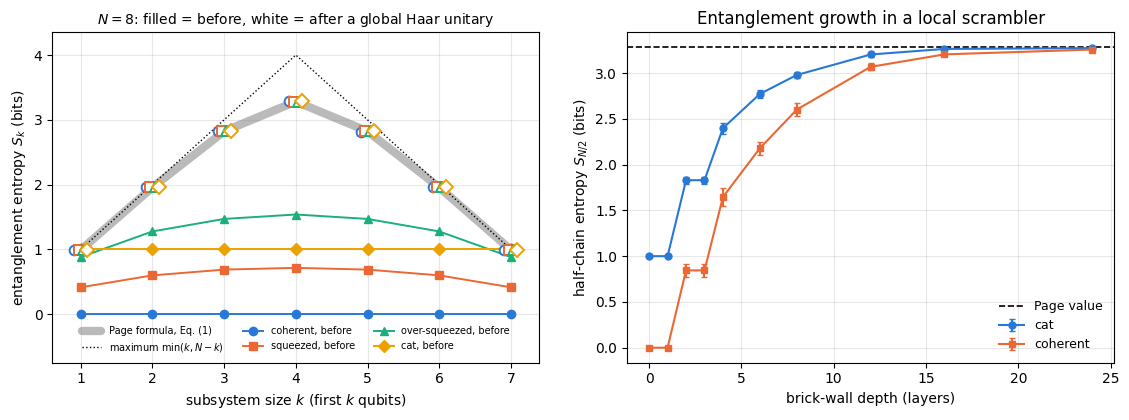

 depth |                    cat               coherent
     0 |     1.000 +-  0.000        0.000 +-  0.000   
     1 |     1.000 +-  0.000        0.000 +-  0.000   
     2 |     1.830 +-  0.037        0.845 +-  0.073   
     3 |     1.830 +-  0.037        0.845 +-  0.073   
     4 |     2.398 +-  0.060        1.646 +-  0.095   
     6 |     2.772 +-  0.047        2.179 +-  0.069   
     8 |     2.979 +-  0.035        2.601 +-  0.067   
    12 |     3.203 +-  0.023        3.068 +-  0.038   
    16 |     3.264 +-  0.015        3.205 +-  0.015   
    24 |     3.273 +-  0.009        3.257 +-  0.014   

Page value at the middle cut: 3.282 bits (maximum 4)


In [7]:
# ==============================================================================
# FIGURE: the Page curve -- before and after scrambling
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.3))
axes[0].plot(CUTS, page_curve, "-", color="0.55", lw=6, alpha=0.6, solid_capstyle="round",
             label="Page formula, Eq. (1)")
axes[0].plot(CUTS, np.minimum(CUTS, N_MAIN - np.array(CUTS)), "k:", lw=1, label=r"maximum $\min(k,N-k)$")
for j, name in enumerate(probes):
    axes[0].plot(CUTS, prof_before[name], MARKERS[j] + "-", color=PALETTE[j], ms=6, lw=1.4,
                 label=PROBE_LBL[name] + ", before")
    axes[0].errorbar(np.array(CUTS) + 0.06 * (j - 1.5), prof_after[name].mean(0), yerr=prof_after[name].std(0),
                     fmt=MARKERS[j], color=PALETTE[j], ms=7, mfc="white", mew=1.4, capsize=2, ls="none")
axes[0].set_xlabel("subsystem size $k$ (first $k$ qubits)")
axes[0].set_ylabel(r"entanglement entropy $S_k$ (bits)")
axes[0].set_ylim(-0.75, 4.35)
axes[0].set_title(f"$N={N_MAIN}$: filled = before, white = after a global Haar unitary", fontsize=10)
axes[0].legend(fontsize=7, ncol=3, loc="lower center")

DEPTHS = [0, 1, 2, 3, 4, 6, 8, 12, 16, 24]
keys_bw = jax.random.split(jax.random.PRNGKey(77), N_BW)
S_half = {}
for name in ("cat", "coherent"):
    vals = []
    for dth in DEPTHS:
        st = [scramble_brickwall(k, probes[name], dth) if dth else probes[name] for k in keys_bw]
        vals.append([float(entanglement_entropy(s, range(N_MAIN // 2))) for s in st])
    S_half[name] = np.array(vals)                                   # (depths, realisations)
for j, name in enumerate(S_half):
    axes[1].errorbar(DEPTHS, S_half[name].mean(1), yerr=S_half[name].std(1) / np.sqrt(N_BW),
                     fmt=MARKERS[j] + "-", color=PALETTE[j], ms=5, capsize=2, label=PROBE_LBL[name])
axes[1].axhline(page_entropy_bits(2 ** (N_MAIN // 2), 2 ** (N_MAIN // 2)), color="k", ls="--", lw=1.2,
                label="Page value")
axes[1].set_xlabel("brick-wall depth (layers)")
axes[1].set_ylabel(r"half-chain entropy $S_{N/2}$ (bits)")
axes[1].set_title("Entanglement growth in a local scrambler")
axes[1].legend(fontsize=9)
fig.tight_layout(); plt.show()

print(f"{'depth':>6s} | " + " ".join(f"{n:>22s}" for n in S_half))
for i, dth in enumerate(DEPTHS):
    print(f"{dth:6d} | " + " ".join(f"{S_half[n][i].mean():9.3f} +- "
                                    f"{S_half[n][i].std() / np.sqrt(N_BW):6.3f}   " for n in S_half))
print(f"\nPage value at the middle cut: {page_entropy_bits(2 ** (N_MAIN // 2), 2 ** (N_MAIN // 2)):.3f} bits "
      f"(maximum {N_MAIN // 2})")

The left panel shows the two regimes. Before scrambling (filled symbols) the entropy profiles are flat and low:
the cat state has exactly one bit at every cut — that is what a two-component superposition carries, no matter
where you cut it — and the coherent state has exactly zero, being a product state. After a single global Haar
unitary (white symbols) *all four* probes lie on Page's curve, with a spread over realisations so small that the
error bars are barely visible: the measured deviation from Eq. (1) never exceeds $0.01$ bit. Scrambling has
multiplied the half-chain entanglement of the cat state by more than three.

The right panel resolves the process in depth. The entropy grows in a staircase — only every second layer contains
a gate straddling the central cut, so the curve is flat in between — and approaches the Page value of $3.282$ bits
after about $16$ layers for $N=8$ ($3.264\pm0.015$ at depth $16$, $3.273\pm0.009$ at depth $24$). The two curves
start from different values (one bit for the cat, zero for the product state), and the gap between them closes
gradually as both approach the Page value: about $0.75$ bit at depth $4$, $0.14$ bit at depth $12$, $0.06$ bit at
depth $16$ and $0.02$ bit at depth $24$.

By every entanglement measure, then, scrambling *improves* the state. Section 6 asks the metrological question.

## 6. The collective quantum Fisher information of a random state

### 6.1 The Haar average, derived

What is $F_Q=4\,\mathrm{Var}(J_{\mathbf n})$ for a state drawn uniformly at random? The calculation needs one
input, the **second moment of the Haar measure** on pure states: for any operators $A,B$ on a $d$-dimensional
space,

$$\mathbb{E}\left[\vert\psi\rangle\langle\psi\vert^{\otimes2}\right]
  =\frac{\mathbb 1+\mathbb S}{d(d+1)}, \tag{2}$$

where $\mathbb S$ is the swap operator on the two copies, $\mathbb S\,(\vert u\rangle\otimes\vert v\rangle)
=\vert v\rangle\otimes\vert u\rangle$. Equation (2) says that the average of two copies of a random state is
proportional to the projector onto the symmetric subspace, $(\mathbb 1+\mathbb S)/2$, whose dimension is
$d(d+1)/2$; this is forced by Schur–Weyl duality, since the average must commute with $U\otimes U$ for every $U$
and the only such operators are combinations of $\mathbb 1$ and $\mathbb S$. Two standard traces follow:

$$\mathbb{E}\left[\langle A\rangle\right]=\frac{\mathrm{Tr}A}{d},\qquad
  \mathbb{E}\left[\langle A\rangle\langle B\rangle\right]
  =\mathrm{Tr}\left[(A\otimes B)\frac{\mathbb 1+\mathbb S}{d(d+1)}\right]
  =\frac{\mathrm{Tr}A\,\mathrm{Tr}B+\mathrm{Tr}(AB)}{d(d+1)}, \tag{3}$$

where we used $\mathrm{Tr}\left[(A\otimes B)\mathbb S\right]=\mathrm{Tr}(AB)$.

Now take $A=B=\tilde G=\sum_q(\mathbf n\cdot\vec\sigma)_q=2J_{\mathbf n}$, so that
$F_Q=\langle\tilde G^2\rangle-\langle\tilde G\rangle^2$ (the convention of `qfi_pure`). Two traces are needed.
Every Pauli operator is traceless, hence

$$\mathrm{Tr}\,\tilde G=0 .$$

For the square, $\tilde G^2=\sum_{q,q'}(\mathbf n\cdot\vec\sigma)_q(\mathbf n\cdot\vec\sigma)_{q'}$. The diagonal
terms give $(\mathbf n\cdot\vec\sigma)^2=\mathbb 1$ for a unit vector $\mathbf n$, so they contribute $N\mathbb 1$;
the off-diagonal terms are products of Paulis on *different* qubits, hence traceless. Therefore

$$\mathrm{Tr}\,\tilde G^2=N\,d .$$

Substituting into Eq. (3),

$$\mathbb{E}\left[\langle\tilde G^2\rangle\right]=\frac{\mathrm{Tr}\tilde G^2}{d}=N,\qquad
  \mathbb{E}\left[\langle\tilde G\rangle^2\right]=\frac{0+\mathrm{Tr}\tilde G^2}{d(d+1)}=\frac{N}{d+1},$$

and therefore

$$\boxed{\;\mathbb{E}\left[F_Q\right]=N-\frac{N}{d+1}=N\,\frac{d}{d+1}\;\xrightarrow[N\to\infty]{}\;N\;}\tag{4}$$

with $d=2^N$. A typical state of the Hilbert space — maximally entangled by the Page criterion — has a collective
quantum Fisher information *below* the standard quantum limit, approaching it exponentially fast from below.

Two remarks that we shall need. **Eq. (4) does not depend on $\mathbf n$**: the derivation used only
$\mathrm{Tr}\tilde G=0$ and $\mathrm{Tr}\tilde G^2=Nd$, which hold for every unit vector. **Eq. (4) is an average,
not a value.** Individual states fluctuate around it, and the largest eigenvalue of the fluctuating $3\times3$
matrix $\mathcal{F}$ is therefore systematically *larger* than $\mathbb E[F_Q]$ — a maximum of correlated random
variables is biased upwards. We measure both quantities separately so the effect cannot be mistaken for physics.

### 6.2 Measurement

In [8]:
# ==============================================================================
# STEP 4: collective QFI before and after a global Haar unitary
# ==============================================================================
d_main = 2 ** N_MAIN
haar_prediction = N_MAIN * d_main / (d_main + 1)


@jax.jit
def qfi_diag_and_max(psi):
    """(F_xx, F_yy, F_zz, lambda_max) of the 3x3 QFI matrix -- fixed-axis values plus the optimised one."""
    F = qfi_matrix(psi)
    return jnp.concatenate([jnp.diag(F), jnp.linalg.eigvalsh(F)[-1:]])


stats = {name: np.array(jax.vmap(qfi_diag_and_max)(st)) for name, st in scrambled.items()}

print(f"N = {N_MAIN},  d = {d_main},  Haar prediction of Eq. (4):  N d/(d+1) = {haar_prediction:.4f}")
print(f"(averages over {N_SAMPLES} global Haar unitaries; +- is the standard error of the mean)\n")
print(f"{'probe':>14s} | {'F_max before':>12s} | {'F_Q(J_z) after':>22s} "
      f"{'mean of F_Q(J_x,J_y,J_z)':>28s} {'F_max after':>22s}")
for name in probes:
    s = stats[name]
    fz, avg3, mx = s[:, 2], s[:, :3].mean(axis=1), s[:, 3]
    print(f"{name:>14s} | {float(qfi_collective_max(probes[name])):12.4f} | "
          f"{fz.mean():10.4f} +- {fz.std() / np.sqrt(N_SAMPLES):<8.4f} "
          f"{avg3.mean():14.4f} +- {avg3.std() / np.sqrt(N_SAMPLES):<8.4f} "
          f"{mx.mean():10.4f} +- {mx.std() / np.sqrt(N_SAMPLES):<8.4f}")

# Pool the INDEPENDENT units: one number per scrambled state (the mean of its three Cartesian values).
# The three diagonal entries of one state are correlated, so they must not be counted as three samples.
pooled_all = np.concatenate([stats[n][:, :3].mean(axis=1) for n in probes])
sem_all = pooled_all.std() / np.sqrt(pooled_all.size)
z = (pooled_all.mean() - haar_prediction) / sem_all
print(f"\nall {pooled_all.size} scrambled states pooled: {pooled_all.mean():.4f} +- {sem_all:.4f}   "
      f"(prediction {haar_prediction:.4f}, deviation {z:+.2f} standard errors)")
assert abs(z) < 4.0

N = 8,  d = 256,  Haar prediction of Eq. (4):  N d/(d+1) = 7.9689
(averages over 48 global Haar unitaries; +- is the standard error of the mean)

         probe | F_max before |         F_Q(J_z) after     mean of F_Q(J_x,J_y,J_z)            F_max after
      coherent |       8.0000 |     7.9010 +- 0.0916           7.9887 +- 0.0579       8.9235 +- 0.0914  
      squeezed |      27.3259 |     7.8560 +- 0.0939           7.9534 +- 0.0642       8.9419 +- 0.0837  


 over-squeezed |      40.0032 |     7.9161 +- 0.0905           7.9931 +- 0.0516       8.9167 +- 0.0846  
           cat |      64.0000 |     7.9269 +- 0.0961           7.9847 +- 0.0528       8.9233 +- 0.0616  

all 192 scrambled states pooled: 7.9800 +- 0.0284   (prediction 7.9689, deviation +0.39 standard errors)


In [9]:
# ==============================================================================
# STEP 5a: scrambled probes really are Haar-random states -- the lemma of Section 4.1, tested
# ==============================================================================
keys_hs = jax.random.split(jax.random.PRNGKey(555), 4 * N_SAMPLES)
direct_haar = np.array(jax.vmap(lambda k: qfi_diag_and_max(haar_state(k, N_MAIN)))(keys_hs))
pooled_scr = pooled_all                                    # one value per scrambled probe (Step 4)
pooled_dir = direct_haar[:, :3].mean(axis=1)               # the same statistic for direct Haar states
print(f"mean of F_Q(J_x,J_y,J_z), scrambled probes    : {pooled_scr.mean():.4f}  "
      f"(sample std {pooled_scr.std():.4f}, {pooled_scr.size} states)")
print(f"mean of F_Q(J_x,J_y,J_z), `haar_state` states : {pooled_dir.mean():.4f}  "
      f"(sample std {pooled_dir.std():.4f}, {pooled_dir.size} states)")
diff = pooled_scr.mean() - pooled_dir.mean()
sed = np.sqrt(pooled_scr.var() / pooled_scr.size + pooled_dir.var() / pooled_dir.size)
print(f"difference of the two means                   : {diff:+.4f} +- {sed:.4f}  "
      f"({diff / sed:+.2f} standard errors)")
assert abs(diff / sed) < 4.0
# power control: with the scrambler skipped, the 192 "scrambled" states would be 48 copies of each probe;
# that sample, run through the same test, must fail it
pooled_raw = np.repeat([float(jnp.trace(qfi_matrix(p))) / 3 for p in probes.values()], N_SAMPLES)
z_raw = (pooled_raw.mean() - pooled_dir.mean()) / np.sqrt(pooled_raw.var() / pooled_raw.size + pooled_dir.var() / pooled_dir.size)
print(f"wrong control (probes NOT scrambled)          : {z_raw:+.2f} standard errors")
assert abs(z_raw) > 4.0

# ==============================================================================
# STEP 5b: Eq. (4) at every N -- fixed-axis QFI of Haar-random states, N = 2 .. 14
# ==============================================================================
N_RANGE = range(2, 15)
scale_rows = []
t0 = time.time()
for N in N_RANGE:
    # small systems fluctuate most and cost least; 4096 samples at N <= 6 give the scan the power to tell
    # Eq. (4) apart from nearby wrong formulas (see the controls below)
    n_s = 4096 if N <= 6 else (512 if N <= 8 else 128)
    ks = jax.random.split(jax.random.PRNGKey(N), n_s)
    out = np.array(jax.vmap(lambda k: qfi_diag_and_max(haar_state(k, N)))(ks))
    vals, mx = out[:, 2], out[:, 3]
    scale_rows.append((N, vals.mean(), vals.std() / np.sqrt(n_s), mx.mean(),
                       mx.std() / np.sqrt(n_s), N * 2 ** N / (2 ** N + 1), n_s, vals.std()))
print(f"\n(N = 2 .. 14 in {time.time() - t0:.1f} s)\n")
print(f"{'N':>3s} {'#':>5s} | {'F_Q(J_z)':>20s} {'N d/(d+1)':>11s} {'diff/sem':>9s} | {'F_max':>20s} "
      f"{'F_max - N':>10s} | {'sd of F_Q(J_z)':>14s} {'(F_max - Nd/(d+1))/sd':>22s}")
worst_z = 0.0
for N, m, se, mm, mse, pred, n_s, sd in scale_rows:
    worst_z = max(worst_z, abs(m - pred) / se)
    print(f"{N:3d} {n_s:5d} | {m:10.4f} +- {se:<7.4f} {pred:11.4f} {(m - pred) / se:9.2f} | "
          f"{mm:10.4f} +- {mse:<7.4f} {mm - N:10.4f} | {sd:14.4f} {(mm - pred) / sd:22.2f}")
print(f"\nlargest deviation from Eq. (4) over the 13 sizes: {worst_z:.2f} standard errors")
assert worst_z < 4.0

# --- POWER CONTROL: two nearby wrong formulas must FAIL the same test --------------------------
for label, wrong in (("N (no 1/(d+1) correction)", lambda N: float(N)),
                     ("N (d-1)/d", lambda N: N * (2 ** N - 1) / 2 ** N)):
    z_wrong = max(abs(m - wrong(N)) / se for N, m, se, *_ in scale_rows)
    print(f"wrong control  E[F_Q] = {label:26s}: largest deviation {z_wrong:6.2f} standard errors")
    assert z_wrong > 4.0

mean of F_Q(J_x,J_y,J_z), scrambled probes    : 7.9800  (sample std 0.3942, 192 states)
mean of F_Q(J_x,J_y,J_z), `haar_state` states : 7.9722  (sample std 0.3762, 192 states)
difference of the two means                   : +0.0078 +- 0.0393  (+0.20 standard errors)


wrong control (probes NOT scrambled)          : +14.20 standard errors



(N = 2 .. 14 in 66.2 s)

  N     # |             F_Q(J_z)   N d/(d+1)  diff/sem |                F_max  F_max - N | sd of F_Q(J_z)  (F_max - Nd/(d+1))/sd
  2  4096 |     1.6048 +- 0.0117       1.6000      0.41 |     2.5057 +- 0.0114      0.5057 |         0.7513                   1.21
  3  4096 |     2.6656 +- 0.0160       2.6667     -0.07 |     4.1587 +- 0.0176      1.1587 |         1.0251                   1.46
  4  4096 |     3.7508 +- 0.0169       3.7647     -0.82 |     5.4015 +- 0.0185      1.4015 |         1.0813                   1.51
  5  4096 |     4.8488 +- 0.0168       4.8485      0.02 |     6.4353 +- 0.0170      1.4353 |         1.0768                   1.47
  6  4096 |     5.9044 +- 0.0147       5.9077     -0.22 |     7.2973 +- 0.0145      1.2973 |         0.9411                   1.48
  7   512 |     6.9276 +- 0.0369       6.9457     -0.49 |     8.1207 +- 0.0330      1.1207 |         0.8339                   1.41
  8   512 |     7.9813 +- 0.0304       7.9689      0.41 |  

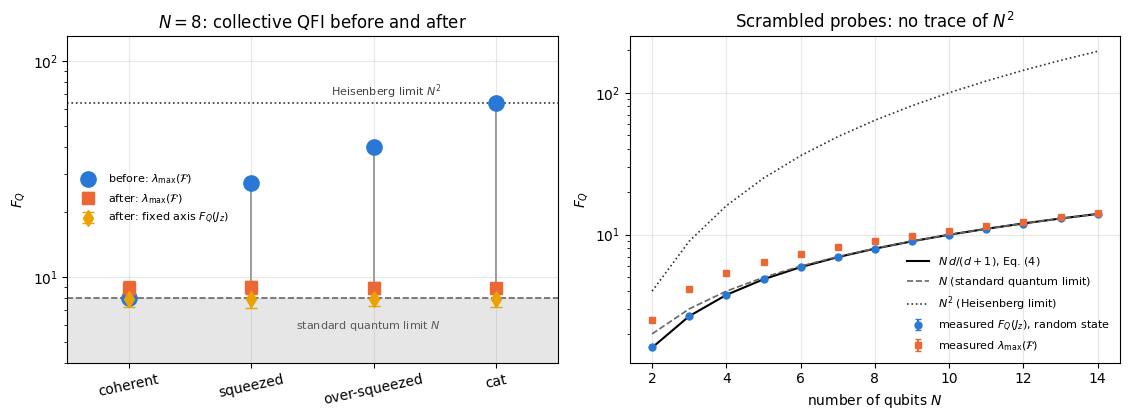

In [10]:
# ==============================================================================
# FIGURE: the metrological collapse
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.3))
xs = np.arange(len(probes))
before = np.array([float(qfi_collective_max(probes[n])) for n in probes])
after_max = np.array([stats[n][:, 3].mean() for n in probes])
after_fix = np.array([stats[n][:, 2].mean() for n in probes])
axes[0].axhspan(1.0, N_MAIN, color="0.9", zorder=0)
axes[0].vlines(xs, after_max, before, color="0.6", lw=1.4, ls="-", zorder=1)
axes[0].plot(xs, before, "o", color=PALETTE[0], ms=11, zorder=3, label=r"before: $\lambda_{\max}(\mathcal{F})$")
axes[0].errorbar(xs, after_max, yerr=[stats[n][:, 3].std() for n in probes], fmt="s", color=PALETTE[1],
                 ms=8, capsize=4, zorder=3, label=r"after: $\lambda_{\max}(\mathcal{F})$")
axes[0].errorbar(xs, after_fix, yerr=[stats[n][:, 2].std() for n in probes], fmt="d", color=PALETTE[3],
                 ms=8, capsize=4, zorder=3, label=r"after: fixed axis $F_Q(J_z)$")
axes[0].axhline(N_MAIN, color="0.4", ls="--", lw=1.2)
axes[0].axhline(N_MAIN ** 2, color="0.2", ls=":", lw=1.2)
axes[0].text(2.55, N_MAIN * 0.72, "standard quantum limit $N$", fontsize=8, color="0.35", ha="right")
axes[0].text(2.55, N_MAIN ** 2 * 1.08, "Heisenberg limit $N^2$", fontsize=8, color="0.25", ha="right")
axes[0].set_yscale("log"); axes[0].set_ylim(4, 130)
axes[0].set_xlim(-0.5, 3.5); axes[0].set_xticks(xs, [PROBE_LBL[n] for n in probes], rotation=12)
axes[0].set_ylabel(r"$F_Q$"); axes[0].set_title(f"$N={N_MAIN}$: collective QFI before and after")
axes[0].legend(fontsize=8, loc="center left")

Ns = np.array([r[0] for r in scale_rows], dtype=float)
axes[1].errorbar(Ns, [r[1] for r in scale_rows], yerr=[r[2] for r in scale_rows], fmt="o", color=PALETTE[0],
                 ms=5, capsize=2, label=r"measured $F_Q(J_z)$, random state")
axes[1].plot(Ns, [r[5] for r in scale_rows], "k-", lw=1.5, label=r"$N\,d/(d+1)$, Eq. (4)")
axes[1].errorbar(Ns, [r[3] for r in scale_rows], yerr=[r[4] for r in scale_rows], fmt="s", color=PALETTE[1],
                 ms=5, capsize=2, label=r"measured $\lambda_{\max}(\mathcal{F})$")
axes[1].plot(Ns, Ns, "--", color="0.4", lw=1.2, label=r"$N$ (standard quantum limit)")
axes[1].plot(Ns, Ns ** 2, ":", color="0.2", lw=1.2, label=r"$N^2$ (Heisenberg limit)")
axes[1].set_xlabel("number of qubits $N$"); axes[1].set_ylabel(r"$F_Q$")
axes[1].set_yscale("log"); axes[1].set_title("Scrambled probes: no trace of $N^2$")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

Averaged over $48$ Haar unitaries, scrambling takes the cat state from $F_Q=N^2=64$ to
$F_Q(J_z)=7.93\pm0.10$. The prediction of Eq. (4) is $7.9689$, and the pooled average over all $192$ scrambled
states is $7.980\pm0.028$, $0.4$ standard errors away. The probes have been *erased*: the coherent state, the
squeezed state, the over-squeezed state and the cat become statistically identical after scrambling, and on average
none of them reaches the standard quantum limit for a fixed collective generator. Step 5a confirms the lemma of
Section 4.1 directly — scrambled probes and states drawn from `haar_state` give means differing by $0.2$ standard
errors, while the same test applied to the unscrambled probes fails by $14$ standard errors. The scan from $N=2$ to
$N=14$ follows Eq. (4) over the whole range (largest deviation $1.9$ standard errors in thirteen tests), a curve
that approaches $N$ from below. The scan also has the power to reject the two nearby wrong answers: $\mathbb E[F_Q]=N$
misses by $34$ standard errors and $N(d-1)/d$ by $9$, both at the smallest sizes, where the $1/(d+1)$ correction is
largest. There is no hint of the $N^2$ the cat started from.

The squares are the trap announced in Section 6.1. Optimising over the direction $\mathbf n$ raises the answer to
$\lambda_{\max}(\mathcal{F})$, measured at $8.92\pm0.06$ for the scrambled cats at $N=8$: about one unit *above*
$N$, hence formally a violation of the separability bound $F_Q\le N$. That excess is the upward bias of a maximum,
and it carries no metrological advantage: $\mathcal{F}$ is a random $3\times3$ matrix whose diagonal entries
fluctuate with a standard deviation of $0.69$ at $N=8$ (printed in the last-but-one column), and its largest
eigenvalue sits above their common mean. The last column tests this explanation quantitatively: the bias
$\lambda_{\max}-Nd/(d+1)$, measured in units of that standard deviation, stays between $1.35$ and $1.56$ from
$N=3$ to $N=14$, while the excess $\lambda_{\max}-N$ itself *peaks* at about $1.4$ near $N=4$–$5$ and falls to
$0.22$ at $N=14$. The
bias is a fixed multiple of a fluctuation that shrinks with the dimension (Exercise 3 derives its size,
$\approx\sqrt{2N(N-1)/(d+1)}$). Against $N^2$, which grows quadratically, it is negligible.

> **Physics insight.** Entanglement entropy went *up* (Section 5) while $F_Q$ went *down* to the standard quantum
> limit. Entanglement is necessary for $F_Q>N$ — a separable state can never exceed it — but it buys nothing by
> itself. What metrology needs is a coherent superposition of two configurations that the *accessible generator*
> separates widely; a random state has its amplitude spread over all $2^N$ configurations, so $J_{\mathbf n}$ has
> the fluctuations of $N$ independent coins and nothing more.

> **Numerical practice.** When a quantity is defined as a maximum over a small set of noisy estimates, its average
> is biased upwards even if every estimate is unbiased. Report the fixed-axis value *and* the optimised value;
> otherwise a fluctuation is easily reported as a discovery.

## 7. Enlarging the search: optimal local generators

Perhaps the scrambled probe is still useful, and we were simply pointing the generator the wrong way. The most
general generator that a laboratory with single-qubit control can implement is a sum of one-qubit terms with an
*independent direction on every qubit*:

$$G_{\rm loc}=\frac12\sum_{q=0}^{N-1}\mathbf n_q\cdot\vec\sigma_q,\qquad
  \mathbf n_q=\left(\sin\vartheta_q\cos\varphi_q,\;\sin\vartheta_q\sin\varphi_q,\;\cos\vartheta_q\right). \tag{5}$$

This class contains the collective generators as the special case $\mathbf n_q\equiv\mathbf n$, so

$$\max_{\{\mathbf n_q\}}F_Q\left[\psi,G_{\rm loc}\right]\;\ge\;\lambda_{\max}(\mathcal{F})$$

always. It also obeys the same separability bound: the proof of $F_Q\le N$ in notebook 29 used only that the
generator is a sum of single-qubit operators with spectrum $\pm\tfrac12$, which Eq. (5) satisfies. So $F_Q>N$
still witnesses entanglement, and $F_Q>kN$ still certifies entanglement depth $k+1$.

Two things are worth noting before we optimise. The Haar average of Eq. (4) applies **unchanged** to every
generator of the form (5): the derivation used only $\mathrm{Tr}\tilde G=0$ and $\mathrm{Tr}\tilde G^2=Nd$, and
for $\tilde G=\sum_q\mathbf n_q\cdot\vec\sigma_q$ both still hold (the cross terms are traceless, the diagonal
ones give $\mathbb 1$ each). So on average *no* local generator is better than any other for a random state, and
whatever the optimisation finds above $Nd/(d+1)$ comes from the fluctuations of a single state.

How large can that be? Write $F_Q$ for Eq. (5) as a quadratic form. With the $3N\times3N$ covariance matrix of all
single-qubit Paulis,

$$\Gamma_{(i,a),(j,b)}=\tfrac12\left\langle\sigma^a_i\sigma^b_j+\sigma^b_j\sigma^a_i\right\rangle
  -\left\langle\sigma^a_i\right\rangle\left\langle\sigma^b_j\right\rangle,\qquad
  F_Q\left[\psi,G_{\rm loc}\right]=\sum_{i,j}\mathbf n_i^{\mathsf T}\,\Gamma_{ij}\,\mathbf n_j ,$$

and the stacked vector $(\mathbf n_0,\dots,\mathbf n_{N-1})$ has squared length $N$. Hence the rigorous bound

$$\max_{\{\mathbf n_q\}}F_Q\left[\psi,G_{\rm loc}\right]\;\le\;N\,\lambda_{\max}(\Gamma). \tag{5a}$$

For a Haar-random state the diagonal entries of $\Gamma$ are $1$ up to corrections of order $1/d$, and each
off-diagonal entry $\langle\sigma^a_i\sigma^b_j\rangle$ is the expectation value of a traceless Pauli string, with
mean $0$ and variance $\mathrm{Tr}(P^2)/[d(d+1)]=1/(d+1)$ by Eq. (3). A symmetric $n\times n$ random matrix with
independent entries of variance $v$ has its largest eigenvalue near $2\sqrt{nv}$ (the edge of Wigner's semicircle),
which suggests the estimate $\lambda_{\max}(\Gamma)\approx1+2\sqrt{3N/(d+1)}$ — an excess that vanishes as
$2^{-N/2}$. The entries of $\Gamma$ are not exactly independent, so this is an estimate to be compared with the
numbers rather than a theorem.

### 7.1 The optimiser

The cost function is

$$C(\vartheta,\varphi)=-F_Q\left[\psi,G_{\rm loc}\right]
  =-\left(\langle\tilde G^2\rangle-\langle\tilde G\rangle^2\right),\qquad
  \tilde G=\sum_q\mathbf n_q\cdot\vec\sigma_q,$$

evaluated matrix-free: build $\vert\phi\rangle=\tilde G\vert\psi\rangle$ with $N$ `apply_gate` calls, then
$\langle\tilde G^2\rangle=\langle\phi\vert\phi\rangle$ and $\langle\tilde G\rangle=\langle\psi\vert\phi\rangle$.
Everything in that chain is a differentiable JAX operation, so `jax.value_and_grad` gives the exact gradient with
respect to all $2N$ angles by reverse-mode differentiation through the einsums — no parameter-shift rule, no
finite differences. Flipping *all* directions, $\mathbf n_q\to-\mathbf n_q$ for every $q$, leaves $F_Q$ invariant,
so maxima come at least in pairs; flipping only some of them changes the sign of the cross terms and gives a
different generator, so the landscape may also have genuinely distinct local maxima. We therefore run several
random restarts in parallel with `vmap`, keep the best, and print the spread of the final values across restarts
to see whether they mattered.

In [11]:
# ==============================================================================
# STEP 6: QFI over site-dependent local generators -- jax.grad + Adam, vmap over restarts
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_RESTART = 16          # random restarts, run in parallel by vmap
N_ADAM = 250            # Adam steps
LR_ADAM = 0.08          # Adam learning rate
# -----------------------------------------------------------------------------


def local_generator_qfi(psi, angles):
    """F_Q of a pure state for the local generator of Eq. (5), given angles of shape (N, 2).

    MATH   G_loc = (1/2) sum_q n_q.sigma_q ;  F_Q = 4 Var(G_loc) = <Gt^2> - <Gt>^2 with Gt = 2 G_loc.
    IMPL   |phi> = Gt|psi> assembled with one `apply_gate` per qubit -> two inner products. O(N 2^N).
    JAX    every step is differentiable, so jax.grad returns the exact gradient in the 2N angles.
    """
    th, ph = angles[:, 0], angles[:, 1]
    nvec = jnp.stack([jnp.sin(th) * jnp.cos(ph), jnp.sin(th) * jnp.sin(ph), jnp.cos(th)], axis=1)   # (N,3)
    phi = jnp.zeros_like(psi)
    for q in range(psi.ndim):
        phi = phi + apply_gate(psi, pauli_direction(nvec[q]), [q])
    return jnp.real(jnp.vdot(phi, phi)) - jnp.real(jnp.vdot(psi, phi)) ** 2


def maximise_local_qfi(key, psi, n_restart=N_RESTART, n_steps=N_ADAM, lr=LR_ADAM):
    """Maximise Eq. (5) over the 2N angles with Adam, starting from `n_restart` random points.

    JAX    `vmap` over the restart axis turns the batch into ONE compiled program; `lax.scan` over the
           Adam steps compiles the loop once instead of unrolling `n_steps` copies of the graph.
    Returns (best F_Q, best angles, history of the best value along the optimisation).
    """
    a0 = jax.random.uniform(key, (n_restart, psi.ndim, 2)) * jnp.array([jnp.pi, 2 * jnp.pi])
    grad_fn = jax.vmap(jax.value_and_grad(lambda a: -local_generator_qfi(psi, a)))

    def step(carry, _):
        a, st = carry
        v, g = grad_fn(a)
        a, st = adam_update(a, g, st, lr=lr)
        return (a, st), jnp.max(-v)

    (a, _), hist = lax.scan(step, (a0, adam_init(a0)), None, length=n_steps)
    vals = jax.vmap(lambda x: local_generator_qfi(psi, x))(a)
    return jnp.max(vals), a[jnp.argmax(vals)], hist, vals


_maximise = jax.jit(maximise_local_qfi, static_argnums=(2, 3))


def local_covariance(psi):
    """3N x 3N covariance matrix of all single-qubit Paulis -- the quadratic form behind Eq. (5).

    MATH   Gamma[(i,a),(j,b)] = (1/2)<{s^a_i, s^b_j}> - <s^a_i><s^b_j>,   F_Q[G_loc] = sum n_i^T Gamma_ij n_j.
           With |n_i| = 1 the stacked vector has squared norm N, so  F_Q[G_loc] <= N * lambda_max(Gamma).
    COST   3N applications of a single-qubit Pauli and (3N)^2 inner products.
    """
    phis = [apply_gate(psi, P, [q]) for q in range(psi.ndim) for P in (X, Y, Z)]
    V = jnp.stack([p.reshape(-1) for p in phis])
    m = jnp.real(V.conj() @ psi.reshape(-1))
    return jnp.real(V.conj() @ V.T) - jnp.outer(m, m)        # real part = symmetrised second moment


t0 = time.time()
local_rows = []
for j, name in enumerate(probes):
    f_b, ang_b, hist_b, v_b = _maximise(jax.random.PRNGKey(10 + j), probes[name])
    st = scrambled[name][0]                                         # one representative scrambled state
    f_a, ang_a, hist_a, v_a = _maximise(jax.random.PRNGKey(30 + j), st)
    bound_a = N_MAIN * float(jnp.linalg.eigvalsh(local_covariance(st))[-1])
    local_rows.append((name, float(qfi_collective_max(probes[name])), float(f_b),
                       float(qfi_collective_max(st)), float(f_a), np.array(hist_b), np.array(hist_a),
                       bound_a, float(jnp.max(v_a) - jnp.min(v_a)), float(jnp.max(v_b) - jnp.min(v_b))))
print(f"(8 optimisations of {N_RESTART} restarts x {N_ADAM} Adam steps in {time.time() - t0:.1f} s)\n")

print(f"{'probe':>14s} | {'collective':>10s} {'local opt.':>10s} {'gain':>6s} || "
      f"{'collective':>10s} {'local opt.':>10s} {'gain':>6s} {'local/N':>8s} {'N lam(Gamma)':>12s} "
      f"{'restart spread':>14s}")
print(f"{'':>14s} | {'--- before scrambling ---':^30s} || {'--- after a global Haar unitary ---':^38s}")
for name, cb, lb, ca, la, _, _, bd, spr, _ in local_rows:
    print(f"{name:>14s} | {cb:10.4f} {lb:10.4f} {lb / cb:6.3f} || {ca:10.4f} {la:10.4f} {la / ca:6.3f} "
          f"{la / N_MAIN:8.3f} {bd:12.4f} {spr:14.2e}")
print(f"\nrestart spread before scrambling (max - min over the {N_RESTART} restarts): "
      + ", ".join(f"{r[0]} {r[9]:.2e}" for r in local_rows))
print(f"random-matrix estimate of the bound, N (1 + 2 sqrt(3N/(d+1))) = "
      f"{N_MAIN * (1 + 2 * np.sqrt(3 * N_MAIN / (d_main + 1))):.3f}")

# --- CHECKPOINT: collective optimum <= local optimum <= N lambda_max(Gamma) ---------------
assert all(lb >= cb - 1e-6 and ca - 1e-6 <= la <= bd + 1e-6 for _, cb, lb, ca, la, _, _, bd, _, _ in local_rows)
print("\nCHECKPOINT  collective optimum <= local optimum <= N lambda_max(Gamma) for all scrambled states, and "
      "local >= collective before scrambling (collective generators are the subset n_q = n)")

(8 optimisations of 16 restarts x 250 Adam steps in 9.7 s)

         probe | collective local opt.   gain || collective local opt.   gain  local/N N lam(Gamma) restart spread
               |   --- before scrambling ---    ||  --- after a global Haar unitary ---  
      coherent |     8.0000     8.0000  1.000 ||     9.7417    14.3539  1.473    1.794      14.7751       5.36e-09
      squeezed |    27.3259    27.3259  1.000 ||     8.8566    12.7102  1.435    1.589      13.0779       7.43e-09
 over-squeezed |    40.0032    40.0032  1.000 ||     9.0053    12.4304  1.380    1.554      12.7867       2.46e-07
           cat |    64.0000    64.0000  1.000 ||     9.0951    12.9319  1.422    1.616      13.0776       2.03e-03

restart spread before scrambling (max - min over the 16 restarts): coherent 2.06e-06, squeezed 3.16e-10, over-squeezed 8.67e-06, cat 8.60e-06
random-matrix estimate of the bound, N (1 + 2 sqrt(3N/(d+1))) = 12.889

CHECKPOINT  collective optimum <= local optimum <= N lambda_

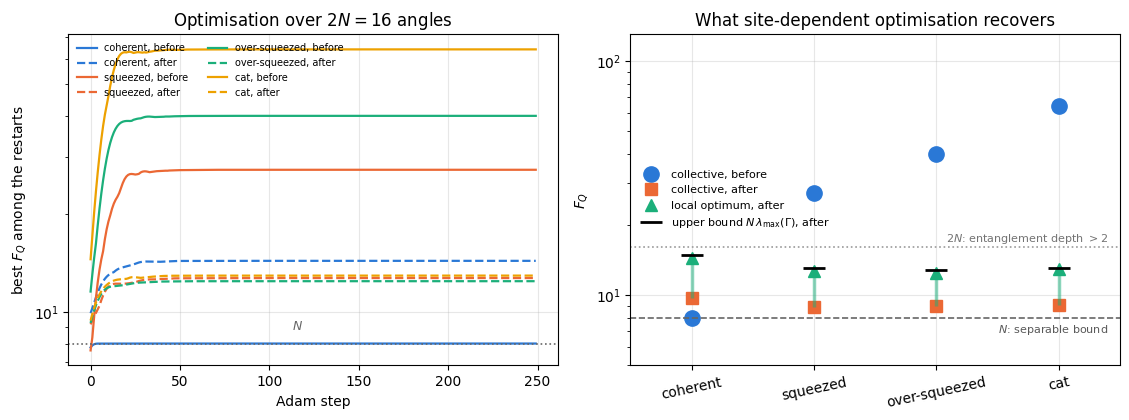

In [12]:
# ==============================================================================
# FIGURE: convergence of the local-generator optimisation, and what it buys
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.3))
for j, (name, cb, lb, ca, la, hb, ha, *_) in enumerate(local_rows):
    axes[0].plot(hb, "-", color=PALETTE[j], lw=1.6, label=f"{PROBE_LBL[name]}, before")
    axes[0].plot(ha, "--", color=PALETTE[j], lw=1.6, label=f"{PROBE_LBL[name]}, after")
axes[0].axhline(N_MAIN, color="0.4", ls=":", lw=1.2)
axes[0].text(N_ADAM * 0.45, N_MAIN * 1.1, "$N$", fontsize=9, color="0.4")
axes[0].set_yscale("log"); axes[0].set_xlabel("Adam step")
axes[0].set_ylabel(r"best $F_Q$ among the restarts")
axes[0].set_title(f"Optimisation over $2N={2 * N_MAIN}$ angles"); axes[0].legend(fontsize=7, ncol=2)

axes[1].plot(xs, [r[1] for r in local_rows], "o", color=PALETTE[0], ms=11, label="collective, before")
axes[1].plot(xs, [r[3] for r in local_rows], "s", color=PALETTE[1], ms=8, label="collective, after")
axes[1].plot(xs, [r[4] for r in local_rows], "^", color=PALETTE[2], ms=9, label="local optimum, after")
axes[1].vlines(xs, [r[3] for r in local_rows], [r[4] for r in local_rows], color=PALETTE[2], lw=2.5, alpha=0.5)
axes[1].plot(xs, [r[7] for r in local_rows], "_", color="k", ms=16, mew=2,
             label=r"upper bound $N\,\lambda_{\max}(\Gamma)$, after")
axes[1].axhline(N_MAIN, color="0.4", ls="--", lw=1.2)
axes[1].axhline(2 * N_MAIN, color="0.6", ls=":", lw=1.2)
axes[1].text(3.4, N_MAIN * 0.86, "$N$: separable bound", fontsize=8, color="0.35", ha="right")
axes[1].text(3.4, 2 * N_MAIN * 1.05, "$2N$: entanglement depth $>2$", fontsize=8, color="0.45", ha="right")
axes[1].set_yscale("log"); axes[1].set_ylim(5, 130); axes[1].set_xlim(-0.5, 3.5)
axes[1].set_xticks(xs, [PROBE_LBL[n] for n in probes], rotation=12)
axes[1].set_ylabel(r"$F_Q$"); axes[1].set_title("What site-dependent optimisation recovers")
axes[1].legend(fontsize=8, loc="center left")
fig.tight_layout(); plt.show()

Before scrambling, the local optimisation finds the collective value for all four probes (the ratio printed in the
"gain" column is $1.000$): for these permutation-symmetric states the best site-dependent generator turns out to be
the uniform one, and the optimiser rediscovering it is a check that it works.

After scrambling the optimum rises from $\lambda_{\max}(\mathcal{F})\approx9$ to between $12.4$ and $14.4$ for the
four realisations shown, that is from about $1.1\,N$ to between $1.55\,N$ and $1.79\,N$. Compared with the cat's
$F_Q=N^2=64$ this is small: $12.9$ is a fifth of it. As an entanglement witness it still certifies something:
$F_Q>N$ certifies entanglement, and the measured values exceed $N=8$ but stay below $2N=16$, so the certified
entanglement depth is $2$ — the weakest non-trivial statement there is, for a state whose entanglement entropy sits
at the Page value.

Two further columns say where the excess comes from. The final values of the $16$ restarts agree to within
$2\times10^{-3}$ for every state, so the restarts are not what sets the optimum: for these states the optimiser
finds the same maximum from every starting point. And every optimum lies just below the bound of Eq. (5a),
$N\lambda_{\max}(\Gamma)$ — $12.93$ against $13.08$ for the scrambled cat — while the random-matrix estimate
$N\left(1+2\sqrt{3N/(d+1)}\right)=12.89$ reproduces the typical size. The excess over $N$ is therefore the edge of
the spectrum of the fluctuating $3N\times3N$ correlation matrix of a random state, which shrinks as $2^{-N/2}$; at
$N=12$ the same estimate gives an optimum of only about $1.19\,N$.

> **JAX practice.** `jax.value_and_grad` differentiates straight through `apply_gate`, i.e. through the einsums
> that build $\tilde G\vert\psi\rangle$. There is no separate "gradient of a quantum circuit" machinery here: the
> simulator is a differentiable function, and reverse-mode automatic differentiation costs a small constant
> multiple of one evaluation (typically two to four), whatever the number of parameters. Wrapping the whole optimisation in `lax.scan` and then
> `jax.jit` compiles the $250$ Adam steps into a single XLA program.

## 8. Where the information went

### 8.1 The invariance identity

Nothing was lost — the scrambler is unitary. The precise statement is an identity, and for pure states it is a
one-line proof. Let $\vert\psi'\rangle=U\vert\psi\rangle$ and $G'=UGU^\dagger$. Then

$$\langle\psi'\vert G'\vert\psi'\rangle=\langle\psi\vert U^\dagger UGU^\dagger U\vert\psi\rangle
  =\langle\psi\vert G\vert\psi\rangle,$$

and the same for $G'^2=UG^2U^\dagger$, so every moment of $G'$ in the scrambled state equals the corresponding
moment of $G$ in the original state. Hence

$$F_Q\left[U\vert\psi\rangle,\;UGU^\dagger\right]=4\,\mathrm{Var}_{U\psi}(UGU^\dagger)
  =4\,\mathrm{Var}_\psi(G)=F_Q\left[\vert\psi\rangle,\;G\right]. \tag{6}$$

The Heisenberg-limited sensitivity of the cat state is still there, in full, in the scrambled state. It is
attached to a different generator.

### 8.2 Complexity of the scrambled generator

Any operator on $N$ qubits expands uniquely in the $4^N$ Pauli strings $P_s=\sigma^{s_0}\otimes\cdots\otimes
\sigma^{s_{N-1}}$, $s_q\in\{0,1,2,3\}$, which are orthogonal under the Hilbert–Schmidt inner product
$\mathrm{Tr}(P_sP_{s'})=d\,\delta_{ss'}$:

$$G'=\sum_s\alpha_sP_s,\qquad \alpha_s=\frac{\mathrm{Tr}\left(P_sG'\right)}{d},\qquad
  \sum_s\alpha_s^2=\frac{\mathrm{Tr}\left(G'^2\right)}{d}=\frac{\mathrm{Tr}\left(G^2\right)}{d}. \tag{7}$$

Call $\vert s\vert$ the **weight** of a string — the number of qubits on which it is not the identity. The
original generator $J_z=\tfrac12\sum_q\sigma^z_q$ has all its weight on the $N$ strings of weight one. What does
$UJ_zU^\dagger$ look like?

There is an exact answer for the Haar average. The trace of $G'$ is zero (unitary conjugation preserves the
trace, and $\mathrm{Tr}J_z=0$), so $\alpha_{s=0}=0$: the identity component vanishes. For all the other $4^N-1$
strings, take any Clifford unitary $C$ — one that maps Pauli strings to Pauli strings up to a sign,
$C^\dagger P_sC=\pm P_{\pi_C(s)}$. Since the Haar measure is invariant, $U$ and $CU$ have the same distribution,
and $\alpha_s(CU)=\mathrm{Tr}\left(P_sCUGU^\dagger C^\dagger\right)/d=\mathrm{Tr}\left(C^\dagger P_sC\,UGU^\dagger\right)/d
=\pm\alpha_{\pi_C(s)}(U)$; hence $\alpha_s^2$ and $\alpha_{\pi_C(s)}^2$ have the same distribution. The Clifford group
acts *transitively* on the non-identity Pauli strings, so $\mathbb{E}\left[\alpha_s^2\right]$ is the same number
for all $s\neq0$, and by Eq. (7) that number is

$$\mathbb{E}\left[\alpha_s^2\right]=\frac{\mathrm{Tr}\left(G^2\right)/d}{4^N-1}\qquad(s\neq0). \tag{8}$$

The number of strings of weight $k$ is $3^k\binom Nk$ (choose the support, then one of $X,Y,Z$ on each of its
qubits), so the expected fraction of the Hilbert–Schmidt weight carried by weight-$k$ strings is

$$w_k=\frac{3^k\binom Nk}{4^N-1}\quad(k\ge1),\qquad w_0=0, \tag{9}$$

the binomial distribution $\binom Nk(3/4)^k(1/4)^{N-k}$ with its $k=0$ term removed and the rest renormalised, with
mean weight

$$\langle k\rangle=\sum_k k\,w_k\approx N\cdot\frac34=\frac{3N}{4}$$

(exactly $3N/4\cdot4^N/(4^N-1)$). A scrambled single-qubit generator is typically a sum of Pauli strings acting on
three quarters of the register, which no realistic interferometer implements.

### 8.3 Computing all $4^N$ coefficients in one pass

The naive route — loop over the $4^N$ strings and evaluate $\mathrm{Tr}(P_sG')$ for each — costs $O(N16^N)$ and is
unusable past $N=5$. The coefficients factorise, so there is a much better way. Write the operator as a rank-$2N$
tensor $A[k_0\ldots k_{N-1};b_0\ldots b_{N-1}]$ (ket indices first, bra indices second), so that
$A=\sum_{k,b}A[k;b]\,\vert k\rangle\langle b\vert$. Then

$$\mathrm{Tr}\left(P_sA\right)=\sum_{k,b}A[k;b]\,\langle b\vert P_s\vert k\rangle
  =\sum_{k,b}A[k;b]\prod_{q=0}^{N-1}\sigma^{s_q}[b_q,k_q].$$

Define the small array $S[s,b,k]=\sigma^s[b,k]$ of shape $(4,2,2)$. The product above is contracted **one qubit at
a time**: contracting the pair of axes $(k_q,b_q)$ of the current tensor with $S$ replaces them by a single axis
of size $4$. For $N=2$ the two steps are, in einsum notation,

* step $q=0$: `"sbk,kKbB->sKB"` — the ket axis $k$ and the bra axis $b$ of qubit $0$ disappear, the Pauli label
  $s$ of qubit $0$ appears;
* step $q=1$: `"sbk,tkb->ts"` — the same for qubit $1$, on the tensor left by the first step.

After $N$ steps the result is a rank-$N$ array indexed by $(s_0,\dots,s_{N-1})$, which *is* the table of all $4^N$
coefficients. Each step costs $O(4^N)$, so the whole decomposition costs $O(N4^N)$ — for $N=6$ that is a few
hundred thousand multiplications instead of a few hundred million.

In [13]:
# ==============================================================================
# STEP 7: the invariance identity, Eq. (6), and the Pauli weight of the scrambled generator
# ==============================================================================
N_PAULI = 6                                        # 4^6 = 4096 strings -- affordable dense decomposition
PAULI_LETTERS = "IXYZ"


def pauli_coefficients(A, N):
    """All 4^N Hilbert-Schmidt coefficients alpha_s = Tr(P_s A)/2^N of a dense operator A.

    MATH   Tr(P_s A) = sum_{k,b} A[k;b] prod_q sigma^{s_q}[b_q, k_q]      (A written as a rank-2N tensor)
    EINSUM one qubit per step, with S[s,b,k] = sigma^s[b,k] of shape (4,2,2):
               N=2, q=0:  "sbk,kKbB->sKB"      N=2, q=1:  "sbk,tkb->ts"
           each step removes one ket axis and one bra axis and creates one Pauli axis of size 4.
    COST   O(N 4^N) instead of the O(N 16^N) of a loop over strings.
    Returns (coefficients, weights) as flat real NumPy arrays of length 4^N, in the order I,X,Y,Z per qubit.
    """
    S = jnp.stack([I2, X, Y, Z])                       # S[s, b, k] = sigma^s[b, k]
    T = jnp.asarray(A, dtype=CDTYPE).reshape((2,) * (2 * N))
    for q in range(N):
        n_left = N - q                                 # kets of qubits q..N-1, then bras of qubits q..N-1
        inp = list(_LETTERS[:T.ndim])
        ket, bra, new = inp[q], inp[q + n_left], _LETTERS[T.ndim]
        out = inp.copy()
        out[q] = new
        out.pop(q + n_left)
        T = jnp.einsum(f"{new}{bra}{ket},{''.join(inp)}->{''.join(out)}", S, T)
    coeffs = np.array(jnp.real(T)).reshape(-1) / 2 ** N
    digits = np.stack(np.unravel_index(np.arange(4 ** N), (4,) * N))       # (N, 4^N) Pauli digits
    return coeffs, (digits != 0).sum(axis=0)


# --- CHECKPOINT: Eq. (6) on a scrambled cat state -------------------------------------
psi_inv = oat_probe(N_PAULI, MU_CAT)
F_inv, n_inv = optimal_direction(psi_inv)
key_inv = jax.random.PRNGKey(3)
U_inv = haar_unitary(key_inv, 2 ** N_PAULI)
psi_scr = (U_inv @ psi_inv.reshape(-1)).reshape((2,) * N_PAULI)
G_dense = collective_dense(pauli_direction(n_inv), N_PAULI)          # the optimal generator n_opt . J
G_scr = U_inv @ G_dense @ U_inv.conj().T                             # U G U^dagger
v = psi_scr.reshape(-1)
m1 = float(jnp.real(jnp.vdot(v, G_scr @ v)))
m2 = float(jnp.real(jnp.vdot(v, G_scr @ (G_scr @ v))))
f_scr_generator = 4 * (m2 - m1 ** 2)
print(f"N = {N_PAULI}, cat state, optimal collective direction n_opt = "
      f"{np.array2string(np.array(n_inv), precision=3, floatmode='fixed')}")
print(f"  F_Q[psi, n_opt.J]                     = {float(F_inv):14.10f}   (= N^2 = {N_PAULI ** 2})")
print(f"  F_Q[U psi, U (n_opt.J) U^dag], Eq. (6) = {f_scr_generator:14.10f}")
print(f"  F_Q[U psi, n_opt.J]  (same generator)  = {float(qfi_matrix(psi_scr) @ np.array(n_inv) @ np.array(n_inv)):14.10f}")
assert abs(f_scr_generator - float(F_inv)) < 1e-6 * N_PAULI ** 2
print(f"\nCHECKPOINT  the invariance identity holds to {abs(f_scr_generator - float(F_inv)):.2e}: "
      f"the information is intact, but only for the transformed generator.")

N = 6, cat state, optimal collective direction n_opt = [1.000 0.000 0.000]
  F_Q[psi, n_opt.J]                     =  36.0000000000   (= N^2 = 36)
  F_Q[U psi, U (n_opt.J) U^dag], Eq. (6) =  36.0000000000
  F_Q[U psi, n_opt.J]  (same generator)  =   6.5107833705

CHECKPOINT  the invariance identity holds to 2.13e-14: the information is intact, but only for the transformed generator.


In [14]:
# ==============================================================================
# STEP 8: Pauli weight spectrum of U J_z U^dagger
# ==============================================================================
Jz_dense = collective_dense(Z, N_PAULI)
coef_before, wts = pauli_coefficients(Jz_dense, N_PAULI)
Gz_scr = U_inv @ Jz_dense @ U_inv.conj().T                          # U J_z U^dagger, same U as in Step 7
t0 = time.time()
coef_after, _ = pauli_coefficients(Gz_scr, N_PAULI)
print(f"(one full decomposition into {4 ** N_PAULI} coefficients in {time.time() - t0:.3f} s)\n")

# --- CHECKPOINT: the fast decomposition against `apply_pauli_string`, string by string --------
# Tested on the SCRAMBLED generator, which has non-zero components on (almost) every string, including strings
# with Y's -- a transposed or conjugated Pauli in the contraction would flip their signs and fail here.
G_tensor = jnp.asarray(Gz_scr).reshape((2,) * (2 * N_PAULI))
err_dec, rng_dec = 0.0, np.random.default_rng(7)
test_idx = np.concatenate([[0, 3, 2 * 4 ** 5 + 2], rng_dec.integers(1, 4 ** N_PAULI, 29)])
for idx in test_idx:
    lab = "".join(PAULI_LETTERS[int(c)] for c in np.unravel_index(idx, (4,) * N_PAULI))
    brute = float(jnp.real(jnp.trace(dm_matrix(apply_pauli_string(G_tensor, lab))))) / 2 ** N_PAULI
    err_dec = max(err_dec, abs(brute - coef_after[idx]))
print(f"CHECKPOINT fast decomposition vs string-by-string traces ({len(test_idx)} strings of U J_z U^dag): "
      f"max error {err_dec:.2e}  (typical |alpha_s| = {np.sqrt(np.mean(coef_after ** 2)):.1e})")
assert err_dec < 1e4 * TOL

spec_before = np.array([np.sum(coef_before[wts == k] ** 2) for k in range(N_PAULI + 1)])
spec_after = np.array([np.sum(coef_after[wts == k] ** 2) for k in range(N_PAULI + 1)])
from math import comb
w_pred = np.array([3.0 ** k * comb(N_PAULI, k) for k in range(N_PAULI + 1)]) / (4 ** N_PAULI - 1)
w_pred[0] = 0.0                                    # the identity component vanishes exactly: Tr(U J_z U^dag) = 0

print(f"Parseval check, Eq. (7):  sum alpha_s^2 = {spec_after.sum():.6f}  vs  Tr(G^2)/d = "
      f"{float(jnp.real(jnp.trace(Jz_dense @ Jz_dense))) / 2 ** N_PAULI:.6f}")
assert abs(spec_after.sum() - N_PAULI / 4) < 1e4 * TOL and abs(coef_after[0]) < 1e4 * TOL   # Eq. (7), alpha_0 = 0
print(f"\n{'weight k':>9s} | {'J_z (before)':>13s} {'U J_z U^dag':>13s} {'Haar predict, Eq. (9)':>22s}")
for k in range(N_PAULI + 1):
    print(f"{k:9d} | {spec_before[k] / spec_before.sum():13.5f} {spec_after[k] / spec_after.sum():13.5f} "
          f"{w_pred[k]:22.5f}")
mean_w = float(np.sum(np.arange(N_PAULI + 1) * spec_after) / spec_after.sum())
print(f"\nmean Pauli weight: before {float(np.sum(np.arange(N_PAULI + 1) * spec_before) / spec_before.sum()):.3f}, "
      f"after {mean_w:.3f}   (Haar prediction (3N/4) 4^N/(4^N-1) = {3 * N_PAULI / 4 * 4 ** N_PAULI / (4 ** N_PAULI - 1):.3f})")

(one full decomposition into 4096 coefficients in 0.008 s)



CHECKPOINT fast decomposition vs string-by-string traces (32 strings of U J_z U^dag): max error 1.04e-17  (typical |alpha_s| = 1.9e-02)
Parseval check, Eq. (7):  sum alpha_s^2 = 1.500000  vs  Tr(G^2)/d = 1.500000

 weight k |  J_z (before)   U J_z U^dag  Haar predict, Eq. (9)
        0 |       0.00000       0.00000                0.00000
        1 |       1.00000       0.00637                0.00440
        2 |       0.00000       0.03090                0.03297
        3 |       0.00000       0.12502                0.13187
        4 |       0.00000       0.29128                0.29670
        5 |       0.00000       0.35813                0.35604
        6 |       0.00000       0.18830                0.17802

mean Pauli weight: before 1.000, after 4.529   (Haar prediction (3N/4) 4^N/(4^N-1) = 4.501)


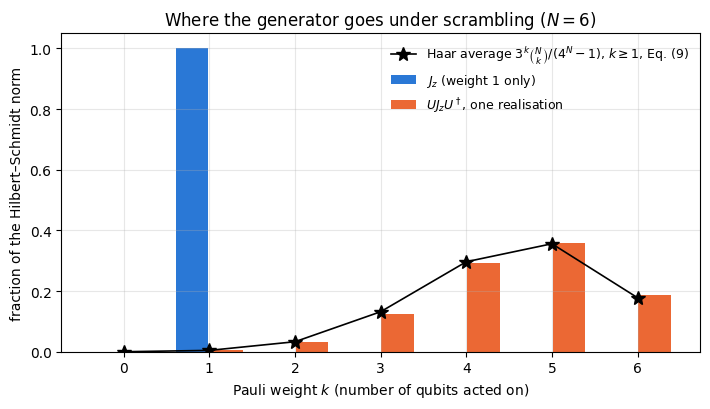

In [15]:
# ==============================================================================
# FIGURE: the generator becomes non-local
# ==============================================================================
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ks = np.arange(N_PAULI + 1)
ax.bar(ks - 0.2, spec_before / spec_before.sum(), width=0.38, color=PALETTE[0], label=r"$J_z$ (weight 1 only)")
ax.bar(ks + 0.2, spec_after / spec_after.sum(), width=0.38, color=PALETTE[1], label=r"$U J_z U^\dagger$, one realisation")
ax.plot(ks, w_pred, "k*-", ms=10, lw=1.2, label=r"Haar average $3^k\binom{N}{k}/(4^N-1)$, $k\geq 1$, Eq. (9)")
ax.set_xlabel("Pauli weight $k$ (number of qubits acted on)")
ax.set_ylabel("fraction of the Hilbert–Schmidt norm")
ax.set_title(f"Where the generator goes under scrambling ($N={N_PAULI}$)")
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

The checkpoint confirms Eq. (6) to $2\times10^{-14}$: measured with the *transformed* generator $UGU^\dagger$, the
scrambled cat still has $F_Q=N^2=36$ to ten digits. Measured with the *original* generator the same state gives
$F_Q=6.51$, just above $N=6$. Nothing was destroyed; the accessible and the inaccessible parts of the operator
algebra were swapped.

The weight spectrum quantifies "inaccessible". $J_z$ is concentrated entirely on weight-one strings. One Haar
unitary (the same $U$ as in the checkpoint) redistributes it over the whole Pauli basis, and the measured spectrum
of $UJ_zU^\dagger$ tracks Eq. (9) closely: the mean weight moves from $1.000$ to $4.529$, against the predicted
$(3N/4)\,4^N/(4^N-1)=4.501$, and the weight-one fraction collapses from $1$ to $0.006$. To use the surviving information one would have to measure a sum of thousands of Pauli strings acting
on typically three quarters of the register — either by implementing $U^\dagger$ on hardware (undoing the
scrambling, which is the information-retrieval protocol of Hayden and Preskill) or by estimating that many
observables from data. Notebook 36 measures exactly how expensive the second route is: the variance of a
shadow estimator grows as $3^k$ with the weight $k$, so an observable of weight $3N/4$ costs $3^{3N/4}$
snapshots.

> **Physics insight.** "Scrambling" has a precise meaning here: simple operators evolve into complicated ones.
> This is the operator-growth picture of quantum chaos (Sekino and Susskind; Hayden and Preskill; Nahum *et al.*),
> and metrology gives it an operational reading: the parameter is still encoded, and reading it requires a
> measurement of exponential complexity.

## 9. Resolving the collapse in time: QFI versus circuit depth

A global Haar unitary is instantaneous. A brick-wall circuit is not, and the natural question is how deep a local
circuit must be to destroy the metrological advantage. The prior expectation from Section 5 would be a depth of
order $N$: that is how long entanglement takes to reach the Page value, and how long it takes a local circuit to
look Haar-random in its low-order statistics.

We measure two things on the same circuits. First, **gate by gate**: after each individual two-qubit gate of the
brick-wall sequence we record $\lambda_{\max}(\mathcal{F})$, the fixed-axis value $F_{xx}=4\,\mathrm{Var}(J_x)$
along the axis of the cat lobes, and the half-chain entropy. Second, **layer by layer** out to depth $24$ for three
system sizes.

### 9.1 The first layer, derived

The first layer can be done exactly on paper. Up to phases that drop out below, the cat is
$\left(\vert a\rangle+\vert b\rangle\right)/\sqrt2$ with $\vert a\rangle=\vert+\rangle^{\otimes N}$ and
$\vert b\rangle=\vert-\rangle^{\otimes N}$. The gates of layer $0$ act on disjoint pairs $p=(2i,2i+1)$; a gate $U_p$
maps the pair's two branch states $\vert{+}{+}\rangle$ and $\vert{-}{-}\rangle$ to $\vert u_p\rangle$ and
$\vert v_p\rangle$, which for a Haar gate are a random *orthonormal* pair in $\mathbb C^4$. After $g$ gates the two
branches are still product states — over the $g$ touched pairs and the $M=N-2g$ untouched qubits — and still
differ on every pair and every untouched qubit. Write $\tilde G=2J_x=\sum_q X_q$, so that $F_{xx}=\mathrm{Var}(\tilde G)$.
$\tilde G$ and $\tilde G^2$ act on at most two qubits at a time, so for $N\ge6$ they have no matrix elements between
the two branches, and the variance of the superposition is that of an equal mixture of the branches:

$$\mathrm{Var}(\tilde G)=\tfrac12\left[\mathrm{Var}_a(\tilde G)+\mathrm{Var}_b(\tilde G)\right]
  +\tfrac14\left(\langle\tilde G\rangle_a-\langle\tilde G\rangle_b\right)^2 .$$

An untouched qubit is an eigenstate of $X$: no variance, and $\pm1$ to the two means. A touched pair contributes,
with $g_p=X_{2i}+X_{2i+1}$, the variance $\mathrm{Var}_{u_p}(g_p)$ (and the same for $v_p$) and the difference
$\delta_p=\langle u_p\vert g_p\vert u_p\rangle-\langle v_p\vert g_p\vert v_p\rangle$. Hence

$$F_{xx}=\sum_p\tfrac12\left[\mathrm{Var}_{u_p}(g_p)+\mathrm{Var}_{v_p}(g_p)\right]
  +\tfrac14\left(2M+\sum_p\delta_p\right)^2 .$$

The Haar averages in dimension $4$ follow from Eq. (3) with $\mathrm{Tr}\,g_p=0$ and $\mathrm{Tr}\,g_p^2=8$:
$\mathbb E\langle g_p^2\rangle=8/4=2$ and $\mathbb E\langle g_p\rangle^2=8/20=2/5$, so
$\mathbb E\,\mathrm{Var}_{u_p}(g_p)=8/5$. For the *orthogonal* partner we need the analogue of Eq. (2) for a random
orthonormal pair: $\mathbb E\left[\vert u\rangle\langle u\vert\otimes\vert v\rangle\langle v\vert\right]$ commutes
with every $U\otimes U$, so it is $\alpha\mathbb 1+\beta\mathbb S$, and the two conditions $\mathrm{Tr}=1$ and
$\mathrm{Tr}\left[\mathbb S\,\cdot\,\right]=\vert\langle u\vert v\rangle\vert^2=0$ give

$$\mathbb E\left[\vert u\rangle\langle u\vert\otimes\vert v\rangle\langle v\vert\right]
  =\frac{\mathbb 1-\mathbb S/d}{d^2-1},\qquad
  \mathbb E\left[\langle u\vert A\vert u\rangle\langle v\vert A\vert v\rangle\right]
  =\frac{(\mathrm{Tr}A)^2-\mathrm{Tr}(A^2)/d}{d^2-1}. \tag{10}$$

With $d=4$ this is $-8/60=-2/15$, so $\mathbb E\,\delta_p^2=2\cdot\tfrac25+2\cdot\tfrac2{15}=\tfrac{16}{15}$.
The $\delta_p$ of different pairs are independent with mean zero, and therefore

$$\mathbb E\left[F_{xx}\right]=(N-2g)^2+\left(\frac85+\frac14\cdot\frac{16}{15}\right)g
  =(N-2g)^2+\frac{28}{15}\,g,\qquad 0\le g\le N/2. \tag{11}$$

The Heisenberg part is the square of the number of *untouched* qubits: every gate removes its pair from the
coherent sum, and what the pair leaves behind, $\delta_p$, adds with a random sign. After the complete first layer
($g=N/2$, $M=0$) Eq. (11) gives $\mathbb E[F_{xx}]=14N/15$, for every even $N$: the $N^2$ excess along the cat axis
is gone after one layer, at any system size. The optimised value $\lambda_{\max}(\mathcal{F})$ is larger than
$F_{xx}$ by the fluctuation bias of Section 6, and that bias is not given by Eq. (11).

### 9.2 Measurement

In [16]:
# ==============================================================================
# STEP 9: QFI and entanglement after every gate of a brick-wall circuit
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_GATE = 10                 # system size for the gate-resolved scan
DEPTH_GATE = 4              # layers followed gate by gate
N_CIRC_GATE = 64            # circuit realisations
# -----------------------------------------------------------------------------


@jax.jit
def gate_diagnostics(psi):
    """[ lambda_max(Fcal) , half-chain entanglement entropy in bits , F_xx ] of one state.

    F_xx = 4 Var(J_x) is the fixed-axis value along the axis of the cat lobes, the quantity of Eq. (11)."""
    F = qfi_matrix(psi)
    return jnp.stack([jnp.linalg.eigvalsh(F)[-1],
                      entanglement_entropy(psi, list(range(psi.ndim // 2))), F[0, 0]])


def gate_resolved_run(key, psi, depth):
    """Apply a brick-wall circuit gate by gate, recording the diagnostics after every gate."""
    out = [gate_diagnostics(psi)]
    for b, U in brickwall_gate_list(key, psi.ndim, depth):
        psi = apply_gate(psi, U, b)
        out.append(gate_diagnostics(psi))
    return np.array(jnp.stack(out))


psi_gate = oat_probe(N_GATE, MU_CAT)
t0 = time.time()
runs = np.stack([gate_resolved_run(jax.random.PRNGKey(400 + j), psi_gate, DEPTH_GATE)
                 for j in range(N_CIRC_GATE)])                      # (circuits, gates+1, 2)
print(f"({N_CIRC_GATE} gate-resolved circuits of {runs.shape[1] - 1} gates in {time.time() - t0:.1f} s)\n")

d_gate = 2 ** N_GATE
print(f"N = {N_GATE}, cat probe (F_Q = N^2 = {N_GATE ** 2}); Haar value of Eq. (4): "
      f"{N_GATE * d_gate / (d_gate + 1):.3f}\n")
def fxx_after_gates(N, g):
    """Eq. (11): Haar average of F_xx = 4 Var(J_x) of the x-cat after g <= N/2 gates on disjoint pairs."""
    return (N - 2 * g) ** 2 + 28 * g / 15


print(f"{'gates applied':>13s} | {'F_max':>20s} {'F_max/N':>8s} | {'F_xx':>20s} {'Eq. (11)':>9s} | "
      f"{'S_(N/2) (bits)':>20s}")
for g in sorted({0, 1, 2, 3, 4, 5, 6, 9, 14, runs.shape[1] - 1}):
    f, s, fx = runs[:, g, 0], runs[:, g, 1], runs[:, g, 2]
    pred = f"{fxx_after_gates(N_GATE, g):9.3f}" if g <= N_GATE // 2 else f"{'-':>9s}"
    print(f"{g:13d} | {f.mean():10.3f} +- {f.std() / np.sqrt(N_CIRC_GATE):<7.3f} {f.mean() / N_GATE:8.3f} | "
          f"{fx.mean():10.3f} +- {fx.std() / np.sqrt(N_CIRC_GATE):<7.3f} {pred} | "
          f"{s.mean():10.3f} +- {s.std() / np.sqrt(N_CIRC_GATE):<7.3f}")

# --- CHECKPOINT: Eq. (11) over the first layer, with a wrong control that must fail ----------------
g_first = np.arange(1, N_GATE // 2 + 1)
sem_x = runs[:, g_first, 2].std(0) / np.sqrt(N_CIRC_GATE)
z_law = (runs[:, g_first, 2].mean(0) - fxx_after_gates(N_GATE, g_first)) / sem_x
geometric = np.maximum(N_GATE ** 2 * 0.6 ** g_first, N_GATE * d_gate / (d_gate + 1))   # "0.6 per gate"
z_geo = (runs[:, g_first, 2].mean(0) - geometric) / sem_x
print(f"\nEq. (11) vs measured F_xx, gates 1..{N_GATE // 2}: deviations {np.array2string(z_law, precision=2)} "
      f"standard errors")
print(f"wrong control, geometric decay 0.6^g: deviations {np.array2string(z_geo, precision=2)} standard errors")
assert np.max(np.abs(z_law)) < 4.0 and np.max(np.abs(z_geo)) > 4.0

(64 gate-resolved circuits of 18 gates in 9.7 s)

N = 10, cat probe (F_Q = N^2 = 100); Haar value of Eq. (4): 9.990

gates applied |                F_max  F_max/N |                 F_xx  Eq. (11) |       S_(N/2) (bits)
            0 |    100.000 +- 0.000     10.000 |    100.000 +- 0.000     100.000 |      1.000 +- 0.000  
            1 |     66.068 +- 1.125      6.607 |     65.446 +- 1.123      65.867 |      1.000 +- 0.000  
            2 |     39.301 +- 0.984      3.930 |     37.966 +- 0.980      39.733 |      1.000 +- 0.000  
            3 |     22.052 +- 0.832      2.205 |     20.070 +- 0.830      21.600 |      1.515 +- 0.026  
            4 |     14.225 +- 0.497      1.422 |     10.972 +- 0.542      11.467 |      1.515 +- 0.026  
            5 |     12.417 +- 0.500      1.242 |      9.185 +- 0.244       9.333 |      1.515 +- 0.026  
            6 |     12.274 +- 0.339      1.227 |      9.289 +- 0.234           - |      1.515 +- 0.026  
            9 |     11.741 +- 0.214      1.174

In [17]:
# ==============================================================================
# STEP 10: layer-resolved scan out to depth 24, for three system sizes
# ==============================================================================
DEPTH_LIST = [0, 1, 2, 3, 4, 6, 8, 12, 16, 24]
N_CIRC_LAYER = 12
depth_data = {}
t0 = time.time()
for N in (6, 8, 10):
    psi_c = oat_probe(N, MU_CAT)
    arr = np.zeros((len(DEPTH_LIST), N_CIRC_LAYER, 3))
    for i, dth in enumerate(DEPTH_LIST):
        for j in range(N_CIRC_LAYER):
            st = scramble_brickwall(jax.random.PRNGKey(1000 * j + 7 * dth + N), psi_c, dth) if dth else psi_c
            arr[i, j] = np.array(gate_diagnostics(st))
    depth_data[N] = arr
print(f"(layer scan in {time.time() - t0:.1f} s)\n")
for N in depth_data:
    dd = 2 ** N
    print(f"N = {N}  (F_Q(cat) = {N ** 2}, Haar value {N * dd / (dd + 1):.3f}, "
          f"Page value {page_entropy_bits(2 ** (N // 2), 2 ** (N - N // 2)):.3f} bits)")
    print(f"   {'depth':>6s} " + " ".join(f"{d:>8d}" for d in DEPTH_LIST))
    print(f"   {'F_max':>6s} " + " ".join(f"{depth_data[N][i, :, 0].mean():8.2f}" for i in range(len(DEPTH_LIST))))
    print(f"   {'S_N/2':>6s} " + " ".join(f"{depth_data[N][i, :, 1].mean():8.2f}" for i in range(len(DEPTH_LIST))))

(layer scan in 48.1 s)

N = 6  (F_Q(cat) = 36, Haar value 5.908, Page value 2.292 bits)
    depth        0        1        2        3        4        6        8       12       16       24
    F_max    36.00     7.43     7.14     7.01     7.12     7.13     7.36     7.36     7.31     7.39
    S_N/2     1.00     1.61     1.54     1.94     1.83     2.14     2.24     2.31     2.28     2.32
N = 8  (F_Q(cat) = 64, Haar value 7.969, Page value 3.282 bits)
    depth        0        1        2        3        4        6        8       12       16       24
    F_max    64.00    10.00     9.72     9.76     9.12     9.10     9.11     8.67     9.02     8.77
    S_N/2     1.00     1.00     1.94     1.85     2.46     2.87     3.02     3.21     3.27     3.29
N = 10  (F_Q(cat) = 100, Haar value 9.990, Page value 4.279 bits)
    depth        0        1        2        3        4        6        8       12       16       24
    F_max   100.00    11.99    12.47    11.28    11.02    10.88    10.75    10.78 

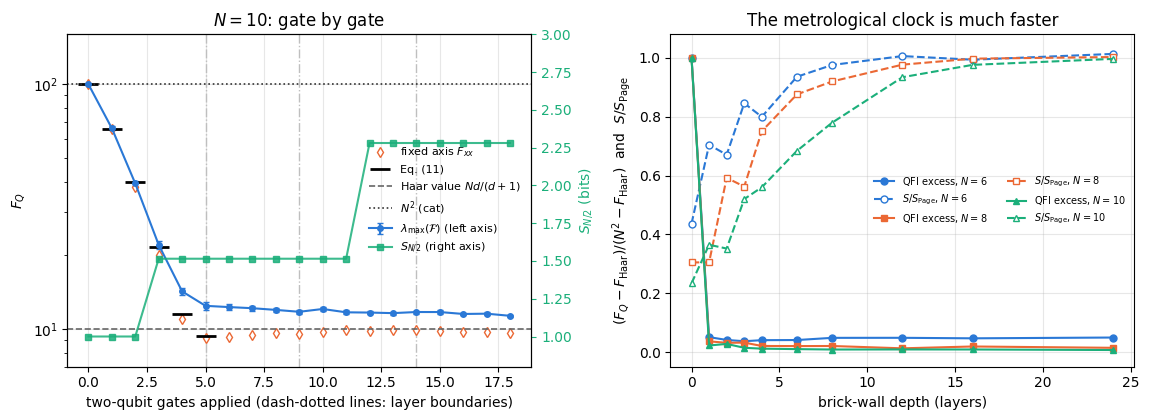

In [18]:
# ==============================================================================
# FIGURE: two clocks -- the QFI clock and the entanglement clock
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.3))
g_axis = np.arange(runs.shape[1])
f_mean, f_sem = runs[:, :, 0].mean(0), runs[:, :, 0].std(0) / np.sqrt(N_CIRC_GATE)
s_mean = runs[:, :, 1].mean(0)
for lay in range(1, DEPTH_GATE):
    axes[0].axvline(sum(len(range((l % 2), N_GATE - 1, 2)) for l in range(lay)), color="0.75", lw=1.0, ls="-.")
axes[0].errorbar(g_axis, f_mean, yerr=f_sem, fmt="o-", color=PALETTE[0], ms=4, capsize=2,
                 label=r"$\lambda_{\max}(\mathcal{F})$ (left axis)")
axes[0].plot(g_axis, runs[:, :, 2].mean(0), "d", color=PALETTE[1], ms=5, mfc="white",
             label=r"fixed axis $F_{xx}$")
g_l0 = np.arange(N_GATE // 2 + 1)
axes[0].plot(g_l0, fxx_after_gates(N_GATE, g_l0), "k_", ms=14, mew=2, label="Eq. (11)")
axes[0].axhline(N_GATE * d_gate / (d_gate + 1), color="0.4", ls="--", lw=1.2,
                label=r"Haar value $N d/(d+1)$")
axes[0].axhline(N_GATE ** 2, color="0.2", ls=":", lw=1.2, label=r"$N^2$ (cat)")
ax2 = axes[0].twinx()
ax2.plot(g_axis, s_mean, "s-", color=PALETTE[2], ms=4, alpha=0.85, label=r"$S_{N/2}$ (right axis)")
ax2.set_ylabel(r"$S_{N/2}$ (bits)", color=PALETTE[2]); ax2.grid(False)
ax2.tick_params(axis="y", colors=PALETTE[2]); ax2.set_ylim(0.8, 3.0)
axes[0].set_yscale("log"); axes[0].set_ylim(7, 160)
axes[0].set_xlabel("two-qubit gates applied (dash-dotted lines: layer boundaries)")
axes[0].set_ylabel(r"$F_Q$"); axes[0].set_title(f"$N={N_GATE}$: gate by gate")
h1, l1 = axes[0].get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
axes[0].legend(h1 + h2, l1 + l2, fontsize=8, loc="center right")

for j, N in enumerate(depth_data):
    dd = 2 ** N
    f_haar = N * dd / (dd + 1)
    norm_f = (depth_data[N][:, :, 0].mean(1) - f_haar) / (N ** 2 - f_haar)
    norm_s = depth_data[N][:, :, 1].mean(1) / page_entropy_bits(2 ** (N // 2), 2 ** (N - N // 2))
    axes[1].plot(DEPTH_LIST, norm_f, MARKERS[j] + "-", color=PALETTE[j], ms=5,
                 label=f"QFI excess, $N={N}$")
    axes[1].plot(DEPTH_LIST, norm_s, MARKERS[j] + "--", color=PALETTE[j], ms=5, mfc="white",
                 label=f"$S/S_{{\\rm Page}}$, $N={N}$")
axes[1].set_xlabel("brick-wall depth (layers)")
axes[1].set_ylabel(r"$(F_Q-F_{\rm Haar})/(N^2-F_{\rm Haar})$  and  $S/S_{\rm Page}$")
axes[1].set_ylim(-0.05, 1.08)
axes[1].set_title("The metrological clock is much faster"); axes[1].legend(fontsize=7, ncol=2, loc="center right")
fig.tight_layout(); plt.show()

The outcome differs from the expectation stated at the start of Section 9.

The gate-resolved panel shows the collapse happening **inside the first layer**. Layer $0$ of a $10$-qubit brick
wall consists of the five gates on the bonds $(0,1),(2,3),\dots,(8,9)$, and the fixed-axis value after each of
them is

$$100\;\to\;65.4\;\to\;38.0\;\to\;20.1\;\to\;11.0\;\to\;9.2,$$

against $100,\,65.9,\,39.7,\,21.6,\,11.5,\,9.3$ from Eq. (11): every point within two standard errors. The
sequence is not a geometric decay. The shape $(N-2g)^2$ — the squared number of qubits no gate has touched yet —
fixes it, and the "factor $0.6$ per gate" that a glance at the first few points suggests is rejected by the
printed control (it misses the first point by about five standard errors). After the fifth gate, the end of the
first layer, $F_{xx}=9.2\pm0.2$, the $14N/15=9.33$ of Eq. (11) and slightly *below* the Haar value $9.99$; over
the next thirteen gates it drifts back up towards it ($9.66\pm0.13$ after $18$ gates). The optimised
$\lambda_{\max}(\mathcal{F})$ follows the same collapse but stays higher — $12.4$ after one layer, $11.3$ after
$18$ gates — the fluctuation bias of Section 6, here larger than for a Haar-random state ($10.6$ at $N=10$) and
relaxing towards it over several layers. The entanglement entropy on the right-hand axis of the same panel has
barely started: it steps up only in the layers containing the gate that straddles the central cut, and needs the
$16$ layers of Section 5 to saturate.

The normalised panel makes the comparison across sizes. Plotted as the fraction of the initial excess that
survives, $(F_Q-F_{\rm Haar})/(N^2-F_{\rm Haar})$ with $F_Q=\lambda_{\max}(\mathcal{F})$, the quantum Fisher
information drops from $1$ to below $0.06$ at depth $1$ for $N=6,8,10$ alike and stays there, while
$S/S_{\rm Page}$ climbs slowly and takes longer the larger the system is. Eq. (11) says why this holds at every
size: after one layer the Heisenberg term $(N-2g)^2$ is exactly zero. The depth on which a local circuit removes the
$N^2$ scaling is therefore one layer, independent of $N$, whereas the depth on which it builds volume-law
entanglement grows as $O(N)$. For a sensor, the first of these two time scales is the relevant one.

In the language of correlations: the collective quantum Fisher information only knows about one- and two-body
correlations, as notebook 36 derives,
$\mathcal{F}_{ab}=N\delta_{ab}+\sum_{i\neq j}\langle\sigma^a_i\sigma^b_j\rangle
-\langle\sum_i\sigma^a_i\rangle\langle\sum_j\sigma^b_j\rangle$. The cat's $N^2$ comes from $\langle X_iX_j\rangle=1$
for all $N(N-1)$ pairs. A gate on pair $p$ replaces the definite values $\pm2$ of $g_p$ in the two branches by the
random difference $\delta_p$, so every correlator involving a touched qubit averages to zero, and one layer touches
every qubit. Building a *volume law* of entanglement, by contrast, requires correlations to propagate across the
whole chain, which takes a time proportional to its length.

> **Common pitfall.** "The circuit is not deep enough to scramble, so my resource is safe" is false for
> metrological resources. Scrambling in the sense of Page-value entanglement is slow; the destruction of
> low-weight correlations — which is all that collective metrology uses — is immediate.

## 10. What a subsystem keeps: the metrological Page curve

Section 5 asked how much *entropy* a subsystem of $k$ qubits has. The metrological question is different: after
the phase has been imprinted on all $N$ qubits by $U(\theta)=e^{-i\theta G}$, how much information about $\theta$
survives in the reduced state of $k$ of them? This is notebook 29, Section 14: the reduced state

$$\rho_A(\theta)=\mathrm{Tr}_B\left[U(\theta)\vert\psi\rangle\langle\psi\vert U^\dagger(\theta)\right]$$

is *mixed*, so its quantum Fisher information needs the symmetric-logarithmic-derivative formula

$$F_Q=2\sum_{m,n\,:\,\lambda_m+\lambda_n>0}
  \frac{\left\vert\langle m\vert\partial_\theta\rho_A\vert n\rangle\right\vert^2}{\lambda_m+\lambda_n},\qquad
  \rho_A=\Psi\Psi^\dagger,\quad\partial_\theta\rho_A=-i\left(T-T^\dagger\right),\quad T=\Phi\Psi^\dagger, \tag{12}$$

where $\Psi$ is the state tensor reshaped into a $2^k\times2^{N-k}$ matrix and $\Phi$ is $G\vert\psi\rangle$
reshaped the same way. The rank of $\rho_A$ is at most $2^{\min(k,N-k)}$, and a thin QR of $[\Psi\;\Phi]$ projects
everything into the active subspace so that keeping $k=N-1$ qubits costs no more than keeping one. We copy that
routine from notebook 29 and use the optimal collective generator of each state.

In [19]:
# ==============================================================================
# STEP 11: QFI of a subsystem, before and after scrambling (Schmidt/QR compressed)
# ==============================================================================
def qfi_from_derivative(rho, drho, tol=1e-12):
    """SLD quantum Fisher information from a state and its derivative -- Eq. (12).

    MATH   F_Q = 2 sum_{m,n} |<m|drho|n>|^2 / (lam_m + lam_n) over lam_m + lam_n > tol, rho = sum_m lam_m |m><m|.
    COST   one Hermitian eigendecomposition, O(dim^3).
    """
    lam, v = jnp.linalg.eigh(rho)
    D = v.conj().T @ drho @ v
    den = lam[:, None] + lam[None, :]
    ok = den > tol
    return 2 * jnp.sum(jnp.where(ok, jnp.abs(D) ** 2 / jnp.where(ok, den, 1.0), 0.0))


def subsystem_qfi(psi, n_dir, K, compress=True, tol=1e-12):
    """QFI of the reduced state of the first K qubits after encoding with G = n.J on all N qubits.

    MATH   Psi = psi reshaped to (2^K, 2^{N-K}), Phi = (n.J psi) reshaped the same way;
           rho_A = Psi Psi^dag,  d rho_A / d theta = -i (T - T^dag) with T = Phi Psi^dag.   [Eq. (12)]
    IMPL   when 2^K > 2^{N-K} a thin QR of [Psi | Phi] gives an isometry onto the (at most 2^{N-K+1})-dimensional
           active subspace; the non-zero spectrum and all matrix elements are unchanged.
    COST   O(8^min(K, N-K)).
    """
    phi = 0.5 * apply_collective(psi, pauli_direction(n_dir))
    Psi = psi.reshape(2 ** K, -1)
    Phi = phi.reshape(2 ** K, -1)
    if compress and Psi.shape[0] > Psi.shape[1]:
        Q, _ = jnp.linalg.qr(jnp.concatenate([Psi, Phi], axis=1))
        Psi, Phi = Q.conj().T @ Psi, Q.conj().T @ Phi
    T = Phi @ Psi.conj().T
    return qfi_from_derivative(Psi @ Psi.conj().T, -1j * (T - T.conj().T), tol)


# --- CHECKPOINT: K = N must reproduce 4 Var(G) ---------------------------------------
for name in ("squeezed", "cat"):
    _, nopt = optimal_direction(probes[name])
    a = float(subsystem_qfi(probes[name], nopt, N_MAIN))
    b = float(qfi_collective_max(probes[name]))
    print(f"K = N check, {name:12s}: subsystem formula {a:12.6f}   4 Var(n_opt.J) {b:12.6f}   "
          f"err {abs(a - b):.2e}")
    assert abs(a - b) < 1e4 * TOL

N_SUB_SAMPLES = 8
sub_before, sub_after = {}, {}
t0 = time.time()
for name, psi in probes.items():
    _, nopt = optimal_direction(psi)
    sub_before[name] = np.array([float(subsystem_qfi(psi, nopt, K)) for K in range(1, N_MAIN + 1)])
    rows = []
    for st in scrambled[name][:N_SUB_SAMPLES]:
        _, n_s = optimal_direction(st)
        rows.append([float(subsystem_qfi(st, n_s, K)) for K in range(1, N_MAIN + 1)])
    sub_after[name] = np.array(rows)
print(f"\n(subsystem QFI for {len(probes)} probes x ({1} + {N_SUB_SAMPLES}) states in {time.time() - t0:.1f} s)\n")

print(f"QFI of the reduced state of the first K qubits, generator = optimal collective direction\n")
print(f"{'probe':>14s} {'when':>7s} | " + " ".join(f"K={K:<6d}" for K in range(1, N_MAIN + 1)))
for name in probes:
    print(f"{name:>14s} {'before':>7s} | " + " ".join(f"{v:7.3f} " for v in sub_before[name]))
    print(f"{'':>14s} {'after':>7s} | " + " ".join(f"{v:7.3f} " for v in sub_after[name].mean(0)))

K = N check, squeezed    : subsystem formula    27.325932   4 Var(n_opt.J)    27.325932   err 1.17e-13
K = N check, cat         : subsystem formula    64.000000   4 Var(n_opt.J)    64.000000   err 2.84e-14



(subsystem QFI for 4 probes x (1 + 8) states in 15.7 s)

QFI of the reduced state of the first K qubits, generator = optimal collective direction

         probe    when | K=1      K=2      K=3      K=4      K=5      K=6      K=7      K=8     
      coherent  before |   1.000    2.000    3.000    4.000    5.000    6.000    7.000    8.000 
                 after |   0.004    0.044    0.367    1.616    4.059    6.197    7.728    9.000 
      squeezed  before |   0.694    1.586    2.756    4.337    6.570    9.949   15.659   27.326 
                 after |   0.010    0.068    0.304    1.592    4.235    6.173    7.683    9.103 
 over-squeezed  before |   0.161    0.605    1.388    2.587    4.548    7.829   14.999   40.003 
                 after |   0.006    0.049    0.355    1.661    4.091    6.186    7.446    8.901 
           cat  before |   0.000    0.000    0.000    0.000    0.000    0.000    0.000   64.000 
                 after |   0.004    0.063    0.310    1.629    4.128    6.08

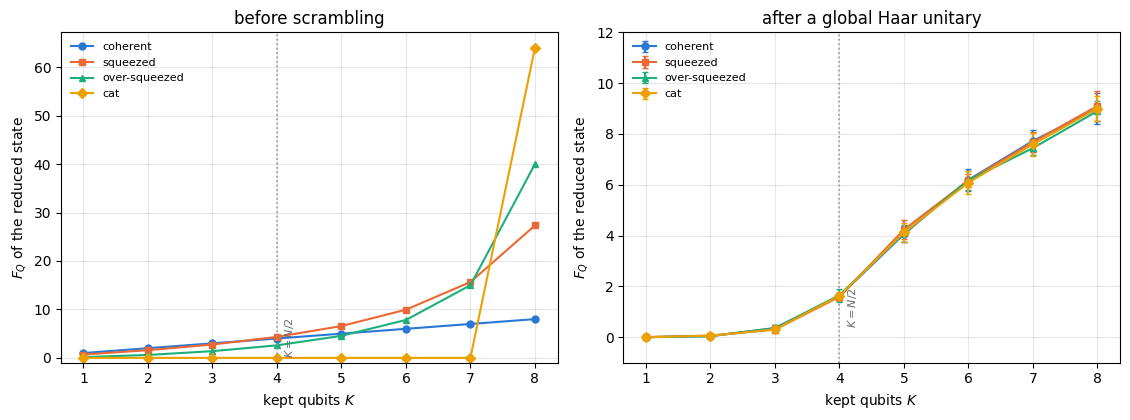

In [20]:
# ==============================================================================
# FIGURE: metrological information versus subsystem size, next to the Page curve
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.3))
Ks = np.arange(1, N_MAIN + 1)
for j, name in enumerate(probes):
    axes[0].plot(Ks, sub_before[name], MARKERS[j] + "-", color=PALETTE[j], ms=5, label=PROBE_LBL[name])
    axes[1].errorbar(Ks, sub_after[name].mean(0), yerr=sub_after[name].std(0), fmt=MARKERS[j] + "-",
                     color=PALETTE[j], ms=5, capsize=2, label=PROBE_LBL[name])
for ax, ttl in zip(axes, ("before scrambling", "after a global Haar unitary")):
    ax.axvline(N_MAIN / 2, color="0.6", ls=":", lw=1.2)
    ax.text(N_MAIN / 2 + 0.1, 0.5, "$K=N/2$", fontsize=8, color="0.4", rotation=90)
    ax.set_xlabel("kept qubits $K$"); ax.set_ylabel(r"$F_Q$ of the reduced state")
    ax.set_title(ttl); ax.legend(fontsize=8)
axes[0].set_ylim(-1, N_MAIN ** 2 * 1.05)
axes[1].set_ylim(-1, 12)
fig.tight_layout(); plt.show()

Before scrambling the four probes behave as notebook 29 found. The cat loses everything the moment a single qubit
is traced out: $F_Q$ drops from $N^2$ to $0$ at $K=N-1$, because the reduced state is a classical mixture of two
eigenstates of the generator and a mixture of eigenstates does not move when the generator acts. The coherent
state loses exactly one unit per lost qubit, $F_Q=K$, as $K$ independent qubits must. The squeezed and
over-squeezed states interpolate, degrading gracefully.

After scrambling the shape is completely different, and it mirrors the Page curve. For
$K\le N/2=4$ the reduced state is nearly maximally mixed — that is what Section 5 measured — and its quantum
Fisher information is nearly zero: about $0.005$, $0.06$, $0.32$ and $1.6$ for $K=1,2,3,4$, the same four numbers
for all four probes to within the scatter. Only beyond the half-way point does information reappear, climbing
steeply to the full-system value of about $9.0$ at $K=N$: about $4.1$ at $K=5$, $6.2$ at $K=6$, $7.6$ at $K=7$.
Half of the register of a scrambled probe holds less than a fifth of the information, and the last qubits added
carry most of it.

This is the metrological face of a well-known statement about scrambled systems: information about a global
property is not stored anywhere locally, it is stored in correlations that require more than half of the system to
read. It is the same threshold at $K=N/2$ that makes the Page curve turn over, and the same mechanism that makes a
scrambled system behave as an "information mirror" in the Hayden–Preskill protocol.

> **Physics insight.** Compare the two panels at $K=1$. Before scrambling, one qubit of the coherent probe is
> worth $F_Q=1$: a working, if modest, sensor. After scrambling, one qubit is worth $0.004$. Scrambling also removes
> the single-particle sensitivity that an unentangled state has without any preparation.

## 11. Cost

| quantity | algorithm | time | memory |
|---|---|---|---|
| $3\times3$ QFI matrix | three collective applications, one $3\times3$ `eigh` | $O(N2^N)$ | $O(2^N)$ |
| global Haar scrambling | Mezzadri QR plus one matrix-vector product | $O(8^N)$ draw, $O(4^N)$ apply | $O(4^N)$ |
| brick-wall layer | $N/2$ two-qubit einsums | $O(N2^N)$ | $O(2^N)$ |
| local-generator optimisation | $R$ restarts $\times$ $S$ Adam steps, reverse-mode gradient | $O(RSN2^N)$ | $O(R2^N)$ |
| subsystem QFI (compressed) | thin QR plus a small `eigh` | $O\!\left(8^{\min(K,N-K)}\right)$ | $O(2^N)$ |
| Pauli decomposition (Section 8.3) | one contraction per qubit | $O(N4^N)$ | $O(4^N)$ |

Two lines deserve comment. Drawing a *global* Haar unitary is the only $O(8^N)$ step in the notebook and it is
what limits Sections 5–8 to $N\le10$; the lemma of Section 4.1 — that $U\vert\psi\rangle$ is a Haar-random state
for every $\vert\psi\rangle$ — let us replace it by `haar_state` in the system-size scan and reach $N=14$ at
$O(2^N)$. And the Pauli decomposition, written naively as a loop over $4^N$ strings, would cost $O(N16^N)$ and
stop at $N=5$; contracting one qubit at a time makes it $O(N4^N)$.

In [21]:
# ==============================================================================
# STEP 12: measured cost of the main primitives
# ==============================================================================
print(f"{'N':>3s} {'d = 2^N':>8s} | {'3x3 QFI matrix [ms]':>20s} {'Haar draw+apply [ms]':>21s} "
      f"{'brickwall depth 4 [ms]':>23s} {'Pauli decomp. [ms]':>19s}")
for N in (4, 6, 8, 10):
    p = oat_probe(N, MU_CAT)
    A = collective_dense(Z, N)                                  # built OUTSIDE the timed region
    _, _, t_q = timed(jax.jit(qfi_collective_max), p, budget=0.1)
    _, _, t_h = timed(jax.jit(scramble_global), jax.random.PRNGKey(0), p, budget=0.25, min_reps=3)
    _, _, t_b = timed(lambda k, s=p: scramble_brickwall(k, s, 4), jax.random.PRNGKey(0), budget=0.1)
    _, _, t_p = timed(pauli_coefficients, A, N, budget=0.1, min_reps=2)
    print(f"{N:3d} {2 ** N:8d} | {t_q * 1e3:20.3f} {t_h * 1e3:21.3f} {t_b * 1e3:23.3f} {t_p * 1e3:19.3f}")

  N  d = 2^N |  3x3 QFI matrix [ms]  Haar draw+apply [ms]  brickwall depth 4 [ms]  Pauli decomp. [ms]


  4       16 |                0.069                 0.161                  16.015               3.276


  6       64 |                0.135                 1.247                  26.459               4.223


  8      256 |                0.590                17.616                  55.681              25.093


 10     1024 |                0.677               925.295                  62.326             513.121


The $3\times3$ matrix stays in the sub-millisecond range at every size — it is $N$ einsums on $2^N$ amplitudes.
Drawing and applying a global Haar unitary, by contrast, grows from a fraction of a millisecond at $N=4$ to
hundreds of milliseconds at $N=10$, and the step from $N=8$ to $N=10$ costs a factor of several tens (between $30$ and
$60$ in our runs, depending on the machine load), of the order of the $8^2=64$ that the QR decomposition of a
$2^N\times2^N$ matrix predicts. (These timings were taken on a shared
machine and vary between runs by a factor of a few; the ratios are more stable than the absolute values.) The
brick-wall column grows far more slowly than the arithmetic would: at these sizes it measures the Python dispatch of a few dozen tiny
einsums and of the QR decompositions that draw the $4\times4$ gates, roughly proportional to the number of gates,
not the arithmetic on the state.

If one wants to push the physics of this notebook to larger systems, the brick-wall scrambler is the way: it is as
cheap as the quantum Fisher information itself, and Section 9 showed that a *single layer* of it already removes
the $N^2$ part of the collective quantum Fisher information at any $N$ (Eq. (11)).

## 12. Key takeaways

* **Scrambling raises entanglement and destroys metrological usefulness.** A global Haar unitary takes every
  one-axis-twisting probe — coherent, squeezed, over-squeezed, cat — onto Page's curve in entropy (measured
  deviation below $0.01$ bit) and onto $F_Q\approx N$ in collective quantum Fisher information. At $N=8$ the cat
  goes from $F_Q=64$ to $F_Q(J_z)=7.93\pm0.10$ (mean over $48$ unitaries).
* **The Haar average is exactly $Nd/(d+1)$, $d=2^N$**, derived from the second moment of the Haar measure
  (Eq. (4)) and confirmed from $N=2$ to $N=14$ (largest deviation $1.9$ standard errors in thirteen tests, while
  the wrong candidates $N$ and $N(d-1)/d$ fail by $34$ and $9$). It holds for *every* generator that is a sum of
  single-qubit terms with unit direction — collective or site-dependent.
* **A scrambled state is a random state.** $U\vert\psi\rangle$ with Haar $U$ is Haar-distributed whatever
  $\vert\psi\rangle$ was, which is why the four probes become indistinguishable. Checked directly: scrambled
  probes and `haar_state` samples agree to $0.2$ standard errors.
* **Entanglement is necessary but not sufficient.** The scrambled states have Page-value entanglement entropy and
  certify an entanglement depth of only $2$, the weakest non-trivial certificate.
* **Optimising over site-dependent local generators recovers little.** With $2N$ free angles, `jax.grad` and Adam
  push $F_Q$ from $\approx9$ to $12.4$–$14.4$ at $N=8$, i.e. from $1.1N$ to about $1.6N$, against the $N^2=64$ the
  probe started with. All restarts reach the same optimum, which sits just below the bound $N\lambda_{\max}(\Gamma)$
  of Eq. (5a); its excess over $N$ is the spectral edge of a random correlation matrix and shrinks as $2^{-N/2}$.
  Before scrambling the same optimisation reproduces the collective value.
* **The information is relocated.** $F_Q[U\psi,UGU^\dagger]=F_Q[\psi,G]$, verified to $2\times10^{-14}$: the
  scrambled cat still has $F_Q=N^2$ for the transformed generator, while the original generator gives $6.51$ at
  $N=6$. The transformed generator has mean Pauli weight close to $3N/4$ (measured $4.529$ against $4.501$ at
  $N=6$) and the weight spectrum $3^k\binom Nk/(4^N-1)$, so reading it requires a measurement of exponential
  complexity.
* **The metrological clock is much faster than the entanglement clock.** In a brick-wall circuit the cat's
  fixed-axis quantum Fisher information after $g$ gates of the first layer is, on average, $(N-2g)^2+28g/15$
  (Eq. (11), derived and confirmed gate by gate at $N=10$): the Heisenberg part is gone after **one layer** at any
  $N$, while the half-chain entropy needs some $16$ layers at $N=8$ to reach the Page value. Collective metrology
  reads only one- and two-body correlations, and one layer of random gates randomises every one of them that
  involves a touched qubit.
* **A subsystem of a scrambled probe holds little below half the register.** The quantum Fisher information of
  $K$ kept qubits is $0.005$, $0.06$, $0.3$, $1.6$ for $K=1,\dots,4$ at $N=8$ and rises steeply afterwards to
  $9.0$ at $K=N$, mirroring the Page curve.
* **Numerics.** A maximum over noisy estimates is biased upwards; we measured the bias ($\lambda_{\max}$ sits
  about one unit above $Nd/(d+1)$ at $N=8$, a fixed multiple $\approx1.45$ of the standard deviation of one
  diagonal entry at every $N$) rather than interpreting it as physics. Reverse-mode automatic differentiation
  through the simulator gives the exact gradient in $2N$ angles at the cost of a few extra state applications, and
  contracting one qubit at a time turns an $O(N16^N)$ Pauli decomposition into an $O(N4^N)$ one.

## 13. Exercises

1. ★ **Read the collapse.** Using Eq. (4), compute $\mathbb E[F_Q]$ for $N=4,10,20$ and the relative deficit
   $1-\mathbb E[F_Q]/N$. At which $N$ does a Haar-random state fall short of the standard quantum limit by less
   than one part in $10^6$? Then compute how many qubits a *product* state would need to match the $F_Q$ of an
   $N=10$ cat state.
2. ★ **The other probes.** Repeat Step 4 with the Dicke state $\vert D_N^{N/2}\rangle$ and the W state instead of
   the one-axis-twisting family (both are in the engine). Do they land on $Nd/(d+1)$ too? They must — explain in
   one sentence why the derivation of Eq. (4) does not care which state was scrambled.
3. ★★ **The size of the bias (extend the code).** Step 5b shows that the bias $\mathbb E[\lambda_{\max}]-Nd/(d+1)$
   stays close to a fixed multiple of the standard deviation of one diagonal entry of $\mathcal{F}$. Derive that
   standard deviation: apply Eq. (3) with $A=B=\tilde G^2$ and $\mathrm{Tr}\,\tilde G^4=d\,(3N^2-2N)$ (prove this
   trace) to show $\mathrm{Var}\left[\langle\tilde G^2\rangle\right]=2N(N-1)/(d+1)$, argue that the fluctuations of
   $\langle\tilde G\rangle^2$ are smaller by a factor of order $1/\sqrt d$, and compare
   $\sqrt{2N(N-1)/(d+1)}$ with the printed column for $N=6,\dots,14$. Why does the bias peak near $N=4$?
4. ★★ **Partial scramblers (extend the code).** Replace the Haar two-qubit gates of the brick-wall circuit by
   $\exp(-i\epsilon h)$, with a fresh $h=(A+A^\dagger)/2$ for every gate and $A$ a $4\times4$ matrix of independent
   standard complex Gaussian entries. At $N=8$, follow the fixed-axis value $F_{xx}$ of the cat versus depth for
   $\epsilon=0.1,0.3,1$, averaged over $\gtrsim20$ circuits. Is the decay of $F_{xx}-Nd/(d+1)$ exponential in the
   depth? Extract a rate and check whether it scales as $\epsilon^2$.
5. ★★ **Correlators of the cat after a few layers (physics).** Using the identity
   $\mathcal{F}_{ab}=N\delta_{ab}+\sum_{i\neq j}\langle\sigma^a_i\sigma^b_j\rangle-\langle\sum_i\sigma^a_i\rangle
   \langle\sum_j\sigma^b_j\rangle$, plot $\langle X_iX_j\rangle$ (the cat lobes lie along $x$) as a function of
   $\vert i-j\vert$ after $0,1,2,4$ brick-wall layers applied to the cat state, averaged over circuits. Reconcile the
   result with Eq. (11) and with the gate-resolved panel of Section 9.
6. ★★ **Decoding by undoing (extend the code).** Apply $U^\dagger$ to a globally scrambled cat ($N=8$) with an
   imperfect inverse, $U^\dagger e^{-i\delta h}$, where $h$ is a random Hermitian $2^N\times2^N$ matrix built as in
   Exercise 4 and normalised to $\mathrm{Tr}(h^2)/d=1$. Plot the recovered $\lambda_{\max}(\mathcal{F})$ and the
   fidelity with the cat against $\delta\in[0.01,1]$. Show that the recovered state is $e^{-i\delta h'}\vert\psi\rangle$
   with $h'=U^\dagger hU$, and estimate the $\delta$ at which half of the cat's $F_Q$ is lost.
7. ★★★ **Beyond local generators (extend the code).** Let $G=\sum_s\alpha_sP_s$ run over all generators supported on
   Pauli strings of weight $1\le\vert s\vert\le w$, with the Hilbert–Schmidt normalisation of $J_z$,
   $\sum_s\alpha_s^2=N/4$ (Eq. (7)). Show that $\max F_Q=N\,\lambda_{\max}(C^{(w)})$ with the covariance matrix
   $C_{st}=\tfrac12\langle P_sP_t+P_tP_s\rangle-\langle P_s\rangle\langle P_t\rangle$ restricted to those strings.
   Compute it for $w=1,\dots,N$ on one globally scrambled cat at $N=6$ and compare with $N^2=36$. Show that for
   $w=N$ the answer is exactly $Nd/2$ (hint: $G\propto\vert\psi\rangle\langle\phi\vert+\vert\phi\rangle\langle\psi\vert$
   with $\langle\phi\vert\psi\rangle=0$), far above $N^2$, and explain why a Hilbert–Schmidt constraint is therefore
   the wrong resource count. What would a spectral constraint, $-N/2\le G\le N/2$, change?
8. ★★★ **The subsystem threshold (physics).** For random states at $N=8,10,12$ (use `haar_state`, not a global
   Haar unitary — Section 4.1 says they are the same thing and the first is $O(2^N)$), locate the value of $K/N$ at
   which the subsystem quantum Fisher information reaches half of its full-system value. Does the threshold
   sharpen towards $1/2$ as $N$ grows, as the Page curve does?

## References

* D. N. Page, *Average entropy of a subsystem*, Phys. Rev. Lett. **71**, 1291 (1993) — Eq. (1), the average
  entanglement entropy of a random pure state and the constant deficit at the symmetric cut.
* S. K. Foong and S. Kanno, *Proof of Page's conjecture on the average entropy of a subsystem*, Phys. Rev. Lett.
  **72**, 1148 (1994), and J. Sánchez-Ruiz, *Simple proof of Page's conjecture on the average entropy of a
  subsystem*, Phys. Rev. E **52**, 5653 (1995) — the proofs of Eq. (1).
* P. Hayden and J. Preskill, *Black holes as mirrors: quantum information in random subsystems*,
  J. High Energy Phys. **2007** (09), 120 (2007) — information about a global property of a scrambled system
  becomes readable only once more than half of it is held; the threshold at $K=N/2$ of Section 10.
* Y. Sekino and L. Susskind, *Fast scramblers*, J. High Energy Phys. **2008** (10), 065 (2008) — the definition
  of scrambling as the growth of simple operators into complicated ones.
* A. Nahum, J. Ruhman, S. Vijay and J. Haah, *Quantum entanglement growth under random unitary dynamics*,
  Phys. Rev. X **7**, 031016 (2017) — entanglement growth in random circuits, the linear-in-depth law and the
  saturation at the Page value used in Section 5.
* F. Mezzadri, *How to generate random matrices from the classical compact groups*, Notices Amer. Math. Soc.
  **54**, 592 (2007) — the QR construction of Haar-random unitaries used by the engine.
* M. Oszmaniec, R. Augusiak, C. Gogolin, J. Kołodyński, A. Acín and M. Lewenstein, *Random bosonic states for
  robust quantum metrology*, Phys. Rev. X **6**, 041044 (2016) — the metrological usefulness of random states,
  and why the answer depends so strongly on which subspace the randomness is drawn from.
* L. Pezzè and A. Smerzi, *Entanglement, nonlinear dynamics, and the Heisenberg limit*,
  Phys. Rev. Lett. **102**, 100401 (2009) — $F_Q>N$ as an entanglement witness.
* P. Hyllus, W. Laskowski, R. Krischek, C. Schwemmer, W. Wieczorek, H. Weinfurter, L. Pezzè and A. Smerzi,
  *Fisher information and multiparticle entanglement*, Phys. Rev. A **85**, 022321 (2012), and G. Tóth,
  *Multipartite entanglement and high-precision metrology*, Phys. Rev. A **85**, 022322 (2012) — the
  entanglement-depth bounds used to read the numbers of Section 7.
* L. Pezzè, A. Smerzi, M. K. Oberthaler, R. Schmied and P. Treutlein, *Quantum metrology with nonclassical states
  of atomic ensembles*, Rev. Mod. Phys. **90**, 035005 (2018) — the standard review of collective-spin metrology.
* M. Kitagawa and M. Ueda, *Squeezed spin states*, Phys. Rev. A **47**, 5138 (1993) — the one-axis-twisting
  Hamiltonian that prepares the probes of Section 3.

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/